# Still-life loop — local MiniMax H3 first/last-frame interpolation

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MNoichl/FluxFlowMorph/blob/agent/chimera-flux-flat-morph/notebooks/StillLife_MiniMax_H3_FL2V_Interpolation.ipynb)

This is a separate downstream notebook. It does **not** regenerate FLUX anchors or
alter any CHIMERA run. It reads the ordered anchor images and their authored prompts
from one completed `base_manifest.json`, renders every adjacent pair (including the
last-to-first closure) with the open MiniMax H3 FL2VA weights on the Colab GPU, and
writes a new resumable run beneath `minimax_h3_interpolations` on Drive.

The default `openai_per_pair` mode sends both endpoint images and both saved prompts to
the Responses API, caches one structured positive-correspondence plan per pair, and prints
the editable writer instructions, correspondence map, and exact H3 prompt before local
rendering. H3 inference itself is always local.


## 1. Editable source, H3, prompt, and finishing settings

`SOURCE_RUN_DIRECTORY=None` discovers the newest completed prompt-only CHIMERA run.
Replace it with an exact Drive directory to pin a particular set of FLUX anchors.
A100 40/80 GB is the recommended Colab target. L4 24 GB selects ComfyUI low-VRAM
offload automatically and is expected to be substantially slower.


In [4]:
PROJECT_ROOT = "/content/FlowMorphKlein9B"
REPOSITORY_URL = "https://github.com/MNoichl/FluxFlowMorph.git"
REPOSITORY_REF = "agent/chimera-flux-flat-morph"

MOUNT_DRIVE = True
DRIVE_PROJECT_BASE = "/content/drive/MyDrive/FluxFlowMorphArt"
SOURCE_PROJECT_NAME = "science_path_prompt_only_chimera"



SOURCE_RUN_DIRECTORY = "science_path_prompt_only_chimera_0016_20260804T173337Z"#None  # Or an exact completed FLUX/CHIMERA run directory.
H3_PROJECT_NAME = "minimax_h3_interpolations"
RESUME_H3_RUN_DIRECTORY = None
LOCAL_ASSET_ROOT = "/content/minimax_h3_interpolation"
HF_CACHE_DIR = "/content/hf_cache"

# Local H3/ComfyUI stack, pinned to the researched open-weight release.
COMFYUI_ROOT = "/content/ComfyUI"
COMFYUI_REPOSITORY = "https://github.com/Comfy-Org/ComfyUI.git"
COMFYUI_REVISION = "2eb609766a749e3104485979615e062e401bab97"
COMFY_CLI_VERSION = "1.15.0"
H3_TEMPLATE_REVISION = "5097de61ef09fe75466716ac0b200515f5ea078f"
H3_TEMPLATE_URL = (
    "https://raw.githubusercontent.com/Comfy-Org/workflow_templates/"
    f"{H3_TEMPLATE_REVISION}/templates/video_minimax_h3_i2v.json"
)
H3_MODEL_REPOSITORY = "Comfy-Org/MiniMax-H3"
H3_MODEL_REVISION = "eb8a16107c595128b3a578f82d2ce2f75920c355"
H3_DIFFUSION_MODEL = "minimax_h3_fl2va_pruned_int8_convrot.safetensors"
H3_TEXT_ENCODER = "qwen3vl_32b_minimax_h3_nvfp4_awq.safetensors"
H3_VIDEO_VAE = "minimax_h3_video_vae_fp16.safetensors"
H3_AUDIO_VAE = "minimax_h3_audio_vae_fp32.safetensors"
H3_COMFY_PORT = 8188

H3_WIDTH = 768
H3_HEIGHT = 768
H3_DURATION_SECONDS = 6.0
H3_FPS = 24
H3_JOB_TIMEOUT_SECONDS = 1800
H3_ENFORCE_SOURCE_ASPECT = True
H3_WORKFLOW_PATCH_VERSION = 5
# The released Qwen3-VL encoder advertises 262,144 positions. Keep generated six-second
# prompts far below that and reserve ample space for both image-conditioning blocks.
H3_TEXT_ENCODER_CONTEXT_TOKENS = 262144
H3_IMAGE_CONDITIONING_TOKEN_RESERVE = 8192
H3_PROMPT_MAX_TEXT_TOKENS = 2048
H3_BASE_SEED = None  # OS entropy on a new run; persisted on Drive.
H3_REUSE_EXISTING_CLIPS = True
RUN_ONE_PAIR_TEST = True
H3_ONE_PAIR_TEST_INDEX = 0
RUN_FULL_H3_SEQUENCE = True
H3_KEEP_NATIVE_AUDIO_IN_PAIR_CLIPS = True  # Final loop is silent for clean joins.

# Positive correspondence language avoids priming H3 with a named transition effect.
H3_BASE_MOTION_PROMPT = (
    "A static locked-off view begins exactly at #Image1. Every visible object remains "
    "opaque, solid, and sharply resolved while its existing boundary continuously "
    "deforms along the shortest path into the corresponding object at the same screen "
    "position in #Image2. Shape, material, texture, and color change through small "
    "coherent updates until the view settles exactly at #Image2."
)
H3_PROMPT_MODE = "openai_per_pair"  # Or "template" for no prompt-planning API call.
H3_INCLUDE_ENDPOINT_PROMPTS_IN_TEMPLATE = False

# Image-aware OpenAI prompt writer. This text is intentionally editable and printed by
# the prompt cell. It follows MiniMax's official FL2VA guide and h3-prompt-writing skill.
H3_OPENAI_PROMPT_GUIDE_VERSION = "minimax-h3-fl2va-positive-correspondence-v2"
H3_OPENAI_PROMPT_WRITER_INSTRUCTIONS = r"""
You write a structured motion plan for MiniMax H3-Base-FL2VA using two endpoint images.
Inspect Picture 1, Picture 2, and both authored image prompts. The images are the visual
ground truth; the authored prompts clarify intended subject matter but cannot override
visible composition.

Follow MiniMax's official FL2VA method:
- Plan exactly one [Shot 1]. It is a Static Shot with unchanged framing, lens, viewpoint,
  crop, background plane, tabletop horizon, and illumination direction.
- Use this chronology: first-frame state -> observable intermediate changes -> progressively
  narrowing differences -> exact last-frame state.
- Do not merely describe two static images. Explain the visible path connecting them.

Build positive object correspondence before writing the motion description:
- Account for every major visible form in Picture 1 and Picture 2, including the background,
  support surface, large objects, and compositionally important small objects.
- Match forms primarily by screen region, silhouette, scale, visual role, material, and
  color. Semantic names are secondary. Keep motion local and choose the shortest coherent
  path compatible with both endpoints.
- For each mapping, state the source form and location, target form and location, and the
  continuous geometric/material changes connecting them. If counts differ, describe opaque
  neighboring forms joining through a continuous neck or one solid form separating through
  a growing indentation; retain continuous surfaces throughout.
- Keep the quantity of visible material, negative-space layout, and object density on a
  gradual endpoint-to-endpoint path. A sparse pair remains sparse.
- Consolidate related forms into 4-10 concise mappings. Each source and target statement
  should be one compact sentence; each path should use no more than three sentences.

Write integrated_multimodal_description as production-ready natural English:
- Begin with [Shot 1], the observed visual style, and the exact Picture 1 composition.
- Describe early, middle, and late observable states. Every sentence must concern visible
  composition, boundary motion, material, texture, color, lighting, or spatial relation.
- Existing boundaries advance through small local increments. Forms remain opaque, solid,
  spatially attached, sharply resolved, and continuously identifiable with their mapping.
- Surface detail develops only toward detail actually visible in Picture 2.
- End by settling into the exact silhouettes, positions, spacing, lighting, and composition
  of Picture 2.
- Use the literal labels Picture 1 and Picture 2. Do not add shots, cuts, camera motion,
  characters, actions, typography, dialogue, sound, production commentary, or unreferenced
  objects. Do not name or propose cinematic transition effects.
- RIJKSOIL is an upstream FLUX LoRA trigger and must never appear in the H3 plan.
- Keep this field between 1,200 and 2,400 characters, including [Shot 1]. Finish every
  thought and end with a complete sentence; never stop at a character or token boundary.

Return only the requested structured fields. Do not include the FL2VA alignment header,
field labels, overall_soundscape, or non_diegetic_music; fixed code adds those exactly.
""".strip()
H3_DISALLOWED_GENERATED_TRANSITION_TERMS = (
    "dissolv",
    "crossfade",
    "wipe",
    "particle cloud",
    "powder cloud",
    "smoke cloud",
    "slideshow",
)

# OpenAI is used only to plan prompts; H3 itself remains local and open-weight.
OPENAI_KEY_FILENAME = "openaiapikey.txt"
OPENAI_MODEL = "gpt-5.6"
OPENAI_REASONING_EFFORT = "medium"
OPENAI_IMAGE_DETAIL = "original"
OPENAI_MAX_OUTPUT_TOKENS = 8000
OPENAI_MAX_ATTEMPTS = 3
OPENAI_H3_DESCRIPTION_MIN_CHARS = 1200
OPENAI_H3_DESCRIPTION_MAX_CHARS = 2400
VISION_IMAGE_MAX_SIDE = 1024
VISION_JPEG_QUALITY = 90

# Native H3 clip assembly and one optional inexpensive RIFE x2 pass.
RUN_RIFE_POSTPROCESS = True
RIFE_REPOSITORY_URL = "https://github.com/hzwer/Practical-RIFE.git"
RIFE_REPOSITORY_REVISION = "17d8c7a1005b37f4c97bfee04e316aaec7fdc536"
RIFE_ROOT = "/content/Practical-RIFE"
RIFE_MODEL_REPOSITORY = "Bash2X/RIFE-Models"
RIFE_MODEL_REVISION = "feaf6d11238b4a1e9f015a5d18c18df152affd20"
RIFE_MODEL_FILENAME = "RIFE_v4.25.zip"
RIFE_MULTIPLIER = 2
RIFE_SCALE = 1.0
RIFE_BATCH_SIZE = 4
RIFE_USE_FP16 = True
RIFE_RETRY_WITH_FP32 = True
RUN_BORDER_FLICKER_CORRECTION = True
BORDER_WIDTH_FRACTION = 0.025
BORDER_FEATHER_FRACTION = 0.040
BORDER_CORRECTION_STRENGTH = 0.65
BORDER_MAX_RGB_SHIFT = 0.025

# Optional final spatial super-resolution. The Stable fork's bundled Triton
# Sparse Sage path is streamed after H3/RIFE have released the GPU.
RUN_FLASHVSR_UPSCALE = True
FLASHVSR_SCALE = 4.0  # The official project strongly recommends its trained 4x setting.
FLASHVSR_INPUT_RESIZE_FACTOR = 0.5  # 768 -> 384 model input -> 1536 output (net 2x).
FLASHVSR_REPOSITORY_URL = "https://github.com/naxci1/ComfyUI-FlashVSR_Stable.git"
FLASHVSR_REPOSITORY_REVISION = "f7f55bae4c0e82b18b190d4b62a977995507c51c"
FLASHVSR_ROOT = "/content/ComfyUI-FlashVSR-Stable"
FLASHVSR_ATTENTION_BACKEND = "sparse_sage_attention"
FLASHVSR_MODEL_REPOSITORY = "JunhaoZhuang/FlashVSR-v1.1"
FLASHVSR_MODEL_REVISION = "ad1aceeac60dbd288e51acea9096b821a8703bee"
FLASHVSR_WEIGHTS_ROOT = "/content/FlashVSR-v1.1"
FLASHVSR_VENV = "/content/flashvsr_stable_venv"
FLASHVSR_REBUILD_ENVIRONMENT = False
FLASHVSR_REUSE_EXISTING_VIDEO = True
FLASHVSR_SEED = 0
FLASHVSR_SPARSE_RATIO = 2.0
FLASHVSR_LOCAL_RANGE = 11  # 11 is steadier; 9 can be a little sharper.
FLASHVSR_COLOR_FIX = True
FLASHVSR_CYCLIC_WARMUP_FRAMES = 16
FLASHVSR_CRF = 16
FLASHVSR_FFMPEG_PRESET = "medium"
FLASHVSR_MIN_FREE_DISK_GIB = 24.0
FLASHVSR_MIN_FREE_CUDA_GIB = 20.0
FLASHVSR_HANDOFF_MAX_TORCH_GIB = 1.0
FLASHVSR_DELETE_LOCAL_H3_CHECKPOINTS_IF_DISK_LOW = True

VIDEO_CRF = 16
DISPLAY_VIDEO_WIDTH = 768
KEEP_LOCAL_WORK_FRAMES = False
STOP_COMFY_WHEN_FINISHED = True
UNASSIGN_RUNTIME_WHEN_FINISHED = False


## 2. Why this local stack

MiniMax released H3's open Base weights with native text/image/video/audio support.
`H3-Base-FL2VA` accepts zero, one, or two images; two images are its first/last-frame
mode. The open release produces 4–15 second, 24 fps video with a native 768-pixel
short edge. MiniMax's hosted Context-IR prompt preprocessor and 2K regeneration model
are not open, so this notebook uses the published Base prompting format and the native
resolution rather than pretending those hosted stages are local.

The official reproducible SGLang serving recipe targets four GPUs. For a single Colab
GPU, the practical supported path is current ComfyUI plus Comfy-Org's official pruned
INT8 FL2VA transformer and NVFP4 Qwen3-VL encoder. Their combined downloads are about
40 GB, so the model cell performs a local-disk preflight. ComfyUI remains running while
all H3 pairs render, allowing its smart model cache/offload to avoid cold-starting every
pair. Only after H3 completes is that memory released for RIFE.

The OpenAI writer follows the base guide's FL2VA three-field format, single-shot bias,
and `first state → observable changes → narrowing differences → last state` sequence.
The Ref2VA guide is used only for its useful label-consistency and explicit visual-state
discipline; its six-section output format is intentionally not sent to the FL2VA model.
The released H3 Qwen3-VL tokenizer and text-encoder configuration advertise a 262,144-token
context, while pinned ComfyUI performs no implicit prompt truncation. This notebook counts
with that exact ComfyUI tokenizer and applies a deliberately conservative 2,048-text-token
ceiling plus an 8,192-token reserve for the two visual conditioning blocks.

Primary references: [MiniMax H3 model card](https://huggingface.co/MiniMaxAI/MiniMax-H3),
[official base/FL2VA prompt guide](https://huggingface.co/MiniMaxAI/MiniMax-H3/blob/main/docs/VIDEO_PROMPT_WRITING_GUIDE_base_en.md),
[official Ref2VA prompt guide](https://huggingface.co/MiniMaxAI/MiniMax-H3/blob/main/docs/VIDEO_PROMPT_WRITING_GUIDE_ref_en.md),
[official H3 prompt-writing skill](https://github.com/MiniMax-AI/MiniMax-H3/tree/main/skills/h3-prompt-writing),
[official FL2VA text-encoder configuration](https://github.com/MiniMax-AI/MiniMax-H3/blob/main/FL2VA/text_encoder/config.json),
[ComfyUI H3 tokenizer implementation](https://github.com/Comfy-Org/ComfyUI/blob/master/comfy/text_encoders/minimax.py),
[OpenAI Structured Outputs edge-case guidance](https://developers.openai.com/api/docs/guides/structured-outputs#tips-for-your-json-schema),
[Comfy-Org H3 weights](https://huggingface.co/Comfy-Org/MiniMax-H3), and
[official ComfyUI H3 workflow](https://github.com/Comfy-Org/workflow_templates/blob/main/templates/video_minimax_h3_i2v.json).


## 3. GPU, fresh repository checkout, and pinned local H3 runtime

Rerunning this cell fetches the current requested repository branch and detaches at its
newest remote commit. It never embeds a portable fallback. ComfyUI itself stays pinned
to the H3-compatible revision above so a later frontend change cannot silently alter
the workflow during a resumed run.


In [5]:
import importlib
import json
import os
import platform
import shutil
import subprocess
import sys
import time
import urllib.request
from pathlib import Path

print({"python": sys.version, "platform": platform.platform()})
try:
    import torch
except ImportError as error:
    raise RuntimeError("PyTorch is missing; select a Colab GPU runtime.") from error
if not torch.cuda.is_available():
    raise RuntimeError("A CUDA GPU runtime is required for local MiniMax H3.")
gpu_name = torch.cuda.get_device_name(0)
gpu_vram_gib = torch.cuda.get_device_properties(0).total_memory / 1024**3
print({"gpu": gpu_name, "vram_gib": round(gpu_vram_gib, 2), "cuda": torch.version.cuda})
if gpu_vram_gib < 22:
    raise RuntimeError("H3 FL2VA needs at least a 24 GB-class GPU; choose L4, A100, or larger.")
if gpu_vram_gib < 35:
    print("L4-class runtime detected: low-VRAM offload will be used; expect slower H3 rendering.")

project_path = Path(PROJECT_ROOT)
if not (project_path / ".git").is_dir():
    subprocess.check_call([
        "git", "clone", "--depth", "1", "--branch", REPOSITORY_REF,
        "--single-branch", REPOSITORY_URL, PROJECT_ROOT,
    ])
else:
    subprocess.check_call([
        "git", "-C", PROJECT_ROOT, "fetch", "--depth", "1", "origin", REPOSITORY_REF,
    ])
    subprocess.check_call([
        "git", "-C", PROJECT_ROOT, "checkout", "--detach", "FETCH_HEAD",
    ])
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-e", PROJECT_ROOT])

required = {
    "openai": "openai>=2,<3",
    "huggingface_hub": "huggingface-hub>=0.34,<1",
    "imageio_ffmpeg": "imageio-ffmpeg>=0.5,<1",
    "pydantic": "pydantic>=2.10,<3",
}
missing = []
for module_name, requirement in required.items():
    try:
        importlib.import_module(module_name)
    except ImportError:
        missing.append(requirement)
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q", f"comfy-cli=={COMFY_CLI_VERSION}"
])

comfy_root = Path(COMFYUI_ROOT)
if not (comfy_root / ".git").is_dir():
    subprocess.check_call([
        "git", "clone", "--filter=blob:none", COMFYUI_REPOSITORY, COMFYUI_ROOT,
    ])
subprocess.check_call([
    "git", "-C", COMFYUI_ROOT, "fetch", "--depth", "1", "origin", COMFYUI_REVISION,
])
subprocess.check_call([
    "git", "-C", COMFYUI_ROOT, "checkout", "--detach", COMFYUI_REVISION,
])
installed_comfy_revision = subprocess.check_output(
    ["git", "-C", COMFYUI_ROOT, "rev-parse", "HEAD"], text=True
).strip()
if installed_comfy_revision != COMFYUI_REVISION:
    raise RuntimeError("ComfyUI did not resolve to the pinned H3 revision")
if not (comfy_root / "comfy_extras" / "nodes_minimax_h3.py").is_file():
    raise RuntimeError("Pinned ComfyUI checkout does not contain MiniMax H3 nodes")
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q", "-r", str(comfy_root / "requirements.txt")
])

template_path = Path(LOCAL_ASSET_ROOT) / "official_video_minimax_h3_i2v.json"
template_path.parent.mkdir(parents=True, exist_ok=True)
urllib.request.urlretrieve(H3_TEMPLATE_URL, template_path)
template_payload = json.loads(template_path.read_text(encoding="utf-8"))
if len(template_payload.get("definitions", {}).get("subgraphs", [])) != 1:
    raise RuntimeError("Downloaded H3 template does not contain the expected subgraph")

package_source = str(project_path / "src")
if package_source not in sys.path:
    sys.path.insert(0, package_source)
importlib.invalidate_caches()
for module_name in tuple(sys.modules):
    if module_name == "flowmorph_klein" or module_name.startswith("flowmorph_klein."):
        del sys.modules[module_name]
from flowmorph_klein.h3_workflow import (
    build_default_h3_prompt,
    cyclic_h3_pairs,
    discover_h3_finishing_source,
    h3_ui_workflow_controls,
    load_h3_anchor_records,
    patch_h3_ui_workflow,
    snap_h3_frame_count,
    stable_h3_fingerprint,
    strip_h3_source_only_tokens,
    validate_h3_canvas,
    wrap_openai_h3_motion,
)
from flowmorph_klein.border_stabilization import (
    BorderStabilizationConfig,
    stabilize_cyclic_borders,
)

validate_h3_canvas(H3_WIDTH, H3_HEIGHT)
H3_FRAME_COUNT = snap_h3_frame_count(H3_DURATION_SECONDS, fps=H3_FPS)
project_commit = subprocess.check_output(
    ["git", "-C", PROJECT_ROOT, "rev-parse", "HEAD"], text=True
).strip()
print({
    "repository_commit": project_commit,
    "comfyui_commit": installed_comfy_revision,
    "h3_frame_count_per_pair": H3_FRAME_COUNT,
    "actual_pair_seconds_before_terminal_dedup": round(H3_FRAME_COUNT / H3_FPS, 4),
})


{'python': '3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]', 'platform': 'Linux-6.6.122+-x86_64-with-glibc2.35'}
{'gpu': 'NVIDIA A100-SXM4-40GB', 'vram_gib': 39.49, 'cuda': '12.8'}
{'repository_commit': 'df3a1282af37ee7032945b134cea5d632e21423d', 'comfyui_commit': '2eb609766a749e3104485979615e062e401bab97', 'h3_frame_count_per_pair': 158, 'actual_pair_seconds_before_terminal_dedup': 6.5833}


## 4. Mount Drive, choose the source run, and reserve a separate H3 run

The source manifest is read-only. Every H3 prompt plan, patched workflow, pair clip,
and final video goes into the new directory printed by this cell. A random run seed is
created once and persisted, so a disconnected session can resume deterministically.


In [6]:
import re
import secrets
from datetime import datetime, timezone

if not MOUNT_DRIVE:
    raise RuntimeError("This notebook expects Google Drive persistence.")
try:
    from google.colab import drive
except ImportError as error:
    raise RuntimeError("Run this notebook in a Colab kernel (VS Code Colab is fine).") from error
drive.mount("/content/drive")
drive_base = Path(DRIVE_PROJECT_BASE)
drive_base.mkdir(parents=True, exist_ok=True)

source_project_directory = drive_base / SOURCE_PROJECT_NAME

def completed_source_runs():
    if not source_project_directory.is_dir():
        return []
    candidates = []
    for candidate in source_project_directory.iterdir():
        manifest = candidate / "metadata" / "base_manifest.json"
        if not candidate.is_dir() or not manifest.is_file():
            continue
        try:
            payload = json.loads(manifest.read_text(encoding="utf-8"))
        except (OSError, json.JSONDecodeError):
            continue
        if payload.get("complete") is True and len(payload.get("records", [])) >= 2:
            candidates.append(candidate)
    return sorted(candidates, key=lambda path: (path.stat().st_mtime, path.name))

if SOURCE_RUN_DIRECTORY is None:
    available_sources = completed_source_runs()
    if not available_sources:
        raise FileNotFoundError(
            f"No completed source run found under {drive_base / SOURCE_PROJECT_NAME}"
        )
    SOURCE_RUN = available_sources[-1]
    source_selection = "latest_completed"
else:
    configured_source = Path(SOURCE_RUN_DIRECTORY).expanduser()
    source_candidates = (
        [configured_source]
        if configured_source.is_absolute()
        else [
            source_project_directory / configured_source,
            drive_base / configured_source,
            configured_source,
        ]
    )
    SOURCE_RUN = next(
        (candidate for candidate in source_candidates if candidate.is_dir()),
        None,
    )
    if SOURCE_RUN is None:
        searched = "\n  - ".join(str(candidate) for candidate in source_candidates)
        raise FileNotFoundError(
            "SOURCE_RUN_DIRECTORY did not resolve to a directory. Searched:\n  - "
            + searched
        )
    source_selection = (
        "explicit_path" if configured_source.is_absolute() else "explicit_basename"
    )

def reserve_h3_run(parent, source_name):
    source_root = Path(parent) / H3_PROJECT_NAME / source_name
    source_root.mkdir(parents=True, exist_ok=True)
    prefix = "h3_fl2va_"
    numbers = []
    for candidate in source_root.iterdir():
        token = candidate.name[len(prefix):].split("_", 1)[0] if candidate.name.startswith(prefix) else ""
        if candidate.is_dir() and token.isdigit():
            numbers.append(int(token))
    number = max(numbers, default=0) + 1
    stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    while True:
        candidate = source_root / f"{prefix}{number:04d}_{stamp}"
        try:
            candidate.mkdir(parents=False, exist_ok=False)
            return candidate
        except FileExistsError:
            number += 1

if RESUME_H3_RUN_DIRECTORY is not None:
    RUN_DIRECTORY = Path(RESUME_H3_RUN_DIRECTORY).expanduser()
    if not RUN_DIRECTORY.is_dir():
        raise FileNotFoundError(f"RESUME_H3_RUN_DIRECTORY does not exist: {RUN_DIRECTORY}")
else:
    RUN_DIRECTORY = reserve_h3_run(drive_base, SOURCE_RUN.name)
for child in ("clips", "metadata", "prompts", "workflows", "video", "diagnostics"):
    (RUN_DIRECTORY / child).mkdir(parents=True, exist_ok=True)
Path(HF_CACHE_DIR).mkdir(parents=True, exist_ok=True)

seed_path = RUN_DIRECTORY / "metadata" / "run_seed.json"
configured_h3_seed = H3_BASE_SEED
if seed_path.is_file():
    H3_BASE_SEED = int(json.loads(seed_path.read_text(encoding="utf-8"))["h3_base_seed"])
    seed_source = "persisted"
else:
    H3_BASE_SEED = (
        int(configured_h3_seed)
        if configured_h3_seed is not None
        else secrets.randbelow(2**63 - 10000)
    )
    seed_path.write_text(
        json.dumps({
            "h3_base_seed": H3_BASE_SEED,
            "source": "configured" if configured_h3_seed is not None else "os_entropy",
        }, indent=2) + "\n",
        encoding="utf-8",
    )
    seed_source = "configured" if configured_h3_seed is not None else "os_entropy"
if not 0 <= H3_BASE_SEED < 2**63:
    raise ValueError("H3_BASE_SEED is outside [0, 2**63)")

OPENAI_CLIENT = None
OPENAI_KEY_PATH = None
if H3_PROMPT_MODE == "openai_per_pair":
    from openai import OpenAI
    OPENAI_KEY_PATH = drive_base / OPENAI_KEY_FILENAME
    if not OPENAI_KEY_PATH.is_file():
        raise FileNotFoundError(
            f"Create {OPENAI_KEY_PATH} with only the OpenAI API key, then rerun this cell."
        )
    api_key = OPENAI_KEY_PATH.read_text(encoding="utf-8").strip()
    if len(api_key) < 20 or any(character.isspace() for character in api_key):
        raise ValueError("OpenAI key file is empty or malformed")
    OPENAI_CLIENT = OpenAI(api_key=api_key)
    del api_key
elif H3_PROMPT_MODE != "template":
    raise ValueError("H3_PROMPT_MODE must be 'template' or 'openai_per_pair'")

run_identity = {
    "project": H3_PROJECT_NAME,
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "source_run": str(SOURCE_RUN),
    "source_selection": source_selection,
    "run_directory": str(RUN_DIRECTORY),
    "repository_commit": project_commit,
    "comfyui_revision": COMFYUI_REVISION,
    "h3_model_revision": H3_MODEL_REVISION,
    "h3_prompt_mode": H3_PROMPT_MODE,
    "h3_base_seed": H3_BASE_SEED,
    "openai_model": OPENAI_MODEL if OPENAI_CLIENT is not None else None,
    "openai_key_value_recorded": False,
}
(RUN_DIRECTORY / "metadata" / "run_identity.json").write_text(
    json.dumps(run_identity, indent=2, ensure_ascii=False) + "\n", encoding="utf-8"
)
print({
    "source_run": str(SOURCE_RUN),
    "source_selection": source_selection,
    "h3_run": str(RUN_DIRECTORY),
    "seed": H3_BASE_SEED,
    "seed_source": seed_source,
    "prompt_mode": H3_PROMPT_MODE,
})


Mounted at /content/drive
{'source_run': '/content/drive/MyDrive/FluxFlowMorphArt/science_path_prompt_only_chimera/science_path_prompt_only_chimera_0016_20260804T173337Z', 'source_selection': 'explicit_basename', 'h3_run': '/content/drive/MyDrive/FluxFlowMorphArt/minimax_h3_interpolations/science_path_prompt_only_chimera_0016_20260804T173337Z/h3_fl2va_0001_20260807T135205Z', 'seed': 8457294012254897029, 'seed_source': 'os_entropy', 'prompt_mode': 'template'}


## 5. Load and inspect the FLUX anchors and saved prompts

Ordering comes exclusively from the selected run's `base_manifest.json`; the notebook
does not guess from filenames. The final anchor is paired back to the first. Paths from
an older Colab mount are recovered by filename inside the selected source run.


### 12 source anchors from `science_path_prompt_only_chimera_0016_20260804T173337Z`

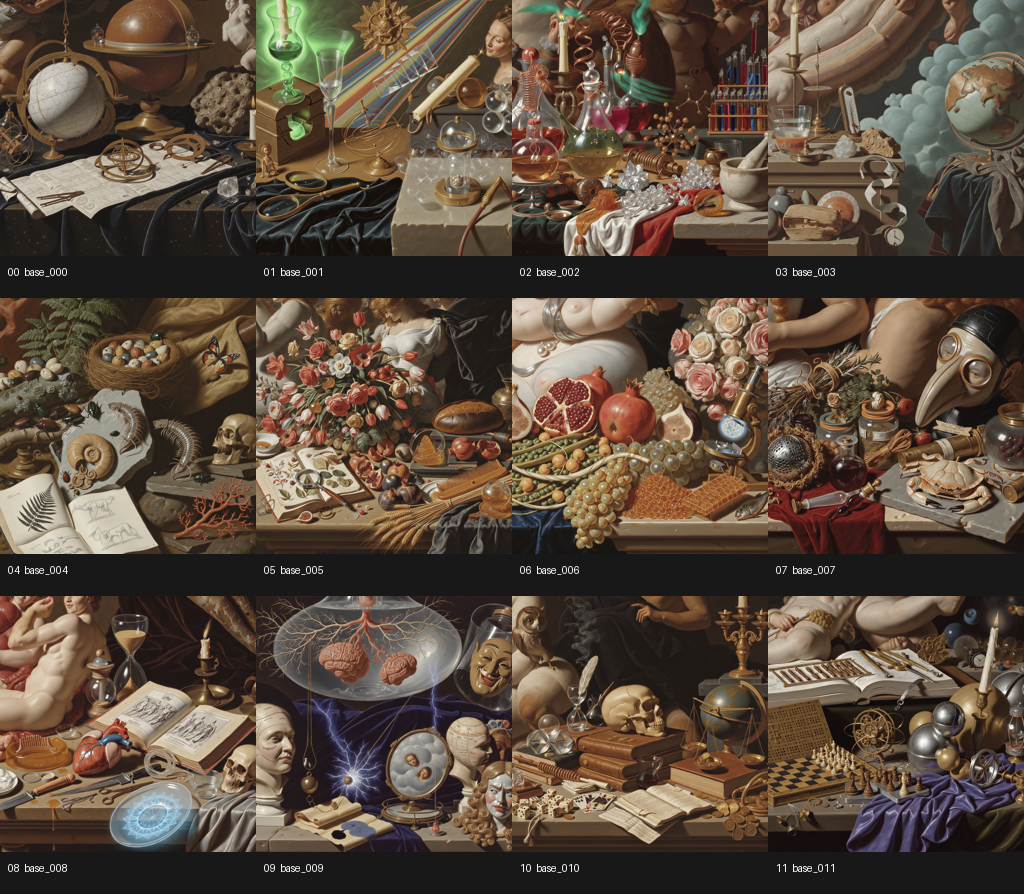


ANCHOR 00: base_000
image: /content/drive/MyDrive/FluxFlowMorphArt/science_path_prompt_only_chimera/science_path_prompt_only_chimera_0016_20260804T173337Z/base_frames/000_01_astronomy.png
saved prompt:
RIJKSOIL, a hushed Baroque still life of the heavens brought indoors: a tarnished brass armillary sphere and a celestial globe painted with constellations, an astrolabe and a small orrery, bronze dividers resting on a curling star chart, a pitted meteorite and a shard of quartz catching the light. A single candle stands in for a distant sun on black velvet strewn with faint points of starlight. Painted as a Dutch Golden Age pronkstilleven, the candle the only light, deep chiaroscuro over dark velvet and worn stone, a cold indigo-black palette shot with silver starlight and old brass, meticulous oil on panel, glinting glass and tarnished brass, a quiet vanitas hush.

ANCHOR 01: base_001
image: /content/drive/MyDrive/FluxFlowMorphArt/science_path_prompt_only_chimera/science_path_prompt_on

In [7]:
from PIL import Image, ImageDraw, ImageFont
from IPython.display import Markdown, display

BASE_RECORDS = load_h3_anchor_records(SOURCE_RUN)
H3_PAIRS = cyclic_h3_pairs(BASE_RECORDS)

thumbnails = []
thumb_size = 256
for record in BASE_RECORDS:
    with Image.open(record["resolved_path"]) as opened:
        image = opened.convert("RGB")
        image.thumbnail((thumb_size, thumb_size))
        canvas = Image.new("RGB", (thumb_size, thumb_size + 42), "#181818")
        canvas.paste(image, ((thumb_size - image.width) // 2, (thumb_size - image.height) // 2))
    draw = ImageDraw.Draw(canvas)
    draw.text((8, thumb_size + 10), f"{record['source_index']:02d}  {record['uid']}", fill="white")
    thumbnails.append(canvas)

source_sizes = []
for record in BASE_RECORDS:
    with Image.open(record["resolved_path"]) as opened:
        source_sizes.append(tuple(opened.size))
source_aspects = [width / height for width, height in source_sizes]
if max(source_aspects) - min(source_aspects) > 0.001:
    raise ValueError(f"Source anchors do not share one aspect ratio: {source_sizes}")
source_aspect = source_aspects[0]
h3_aspect = H3_WIDTH / H3_HEIGHT
if H3_ENFORCE_SOURCE_ASPECT and abs(source_aspect - h3_aspect) > 0.001:
    raise ValueError(
        f"Source aspect {source_aspect:.5f} does not match H3 canvas "
        f"{H3_WIDTH}x{H3_HEIGHT} ({h3_aspect:.5f}). Set H3_WIDTH/H3_HEIGHT to a "
        "native H3 canvas with the same ratio; refusing to crop or stretch silently."
    )
columns = min(4, len(thumbnails))
rows = (len(thumbnails) + columns - 1) // columns
sheet = Image.new("RGB", (columns * thumb_size, rows * (thumb_size + 42)), "#080808")
for index, thumbnail in enumerate(thumbnails):
    sheet.paste(thumbnail, ((index % columns) * thumb_size, (index // columns) * (thumb_size + 42)))
display(Markdown(f"### {len(BASE_RECORDS)} source anchors from `{SOURCE_RUN.name}`"))
display(sheet)

for record in BASE_RECORDS:
    print("\n" + "=" * 100)
    print(f"ANCHOR {record['source_index']:02d}: {record['uid']}")
    print("image:", record["resolved_path"])
    print("saved prompt:")
    print(record["authored_prompt"])
print("\nCyclic pair order:")
for pair in H3_PAIRS:
    print(f"  {pair['index']:02d}: {pair['left']['uid']} -> {pair['right']['uid']}")
print({"source_sizes": sorted(set(source_sizes)), "h3_canvas": (H3_WIDTH, H3_HEIGHT)})


## 6. Build, cache, and print one H3 prompt per pair

In the default `openai_per_pair` mode, GPT sees both actual endpoint images and both
immutable saved prompts, then writes an explicit screen-position correspondence map and
chronological motion path. The editable `H3_OPENAI_PROMPT_WRITER_INSTRUCTIONS` in the
settings cell follows MiniMax's official FL2VA sequence: first-frame state, observable
intermediate changes, progressively narrowing differences, and exact last-frame state.
Fixed code rejects incomplete sentences and incomplete API responses, adds the official
alignment header and three-field H3 format, then counts the final prompt with ComfyUI's
exact H3 tokenizer. The writer instructions, every correspondence map, token count, and
every final transition prompt are printed.
The FLUX-only `RIJKSOIL` LoRA token is never sent to H3.


In [ ]:
import base64
import hashlib
import io
from pydantic import BaseModel, Field
from flowmorph_klein.h3_workflow import validate_h3_prompt_token_budget

comfy_source = str(Path(COMFYUI_ROOT))
if comfy_source not in sys.path:
    sys.path.insert(0, comfy_source)
from comfy.text_encoders.minimax import MiniMaxH3Tokenizer

H3_COMFY_TOKENIZER = MiniMaxH3Tokenizer()
H3_QWEN_TOKENIZER = H3_COMFY_TOKENIZER.qwen3vl_32b.tokenizer

def h3_prompt_text_tokens(prompt):
    return validate_h3_prompt_token_budget(
        prompt,
        tokenizer=H3_QWEN_TOKENIZER,
        max_text_tokens=H3_PROMPT_MAX_TEXT_TOKENS,
        model_context_tokens=H3_TEXT_ENCODER_CONTEXT_TOKENS,
        reserved_condition_tokens=H3_IMAGE_CONDITIONING_TOKEN_RESERVE,
    )

class H3ObjectCorrespondence(BaseModel):
    source_form_and_region: str = Field(min_length=15, max_length=240)
    target_form_and_region: str = Field(min_length=15, max_length=240)
    continuous_path: str = Field(min_length=25, max_length=500)

class H3MotionProposal(BaseModel):
    object_correspondences: list[H3ObjectCorrespondence] = Field(
        min_length=4, max_length=10
    )
    integrated_multimodal_description: str = Field(
        min_length=OPENAI_H3_DESCRIPTION_MIN_CHARS,
        max_length=OPENAI_H3_DESCRIPTION_MAX_CHARS + 200,
    )

def validate_openai_motion_proposal(proposal):
    description = proposal.integrated_multimodal_description.strip()
    if len(description) > OPENAI_H3_DESCRIPTION_MAX_CHARS:
        raise ValueError(
            f"OpenAI H3 description has {len(description)} characters; compact it to "
            f"at most {OPENAI_H3_DESCRIPTION_MAX_CHARS}"
        )
    if not re.search(r'[.!?]["\u201d\u2019\']?$', description):
        raise ValueError("OpenAI H3 description ended mid-sentence")
    required = ("[Shot 1]", "Picture 1", "Picture 2", "Static Shot")
    missing = [item for item in required if item.lower() not in description.lower()]
    if missing:
        raise ValueError(f"OpenAI H3 description is missing required FL2VA anchors: {missing}")
    if not description.lower().startswith("[shot 1]") or description.lower().count("[shot 1]") != 1:
        raise ValueError("OpenAI H3 description must contain exactly one opening [Shot 1]")
    forbidden_structure = (
        "[Shot 2]",
        "integrated_multimodal_description:",
        "overall_soundscape:",
        "non_diegetic_music:",
    )
    leaked_structure = [
        item for item in forbidden_structure if item.lower() in description.lower()
    ]
    if leaked_structure:
        raise ValueError(f"OpenAI H3 description leaked fixed prompt structure: {leaked_structure}")
    proposal_text = " ".join(
        [description]
        + [
            " ".join((item.source_form_and_region, item.target_form_and_region, item.continuous_path))
            for item in proposal.object_correspondences
        ]
    )
    if "RIJKSOIL" in proposal_text.upper():
        raise ValueError("OpenAI H3 proposal leaked the upstream FLUX LoRA token")
    named_effects = [
        term
        for term in H3_DISALLOWED_GENERATED_TRANSITION_TERMS
        if term.lower() in description.lower()
    ]
    if named_effects:
        raise ValueError(
            f"OpenAI H3 description named disallowed transition effects: {named_effects}"
        )

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def image_data_url(path):
    with Image.open(path) as opened:
        image = opened.convert("RGB")
        image.thumbnail((VISION_IMAGE_MAX_SIDE, VISION_IMAGE_MAX_SIDE))
        buffer = io.BytesIO()
        image.save(buffer, format="JPEG", quality=VISION_JPEG_QUALITY, optimize=True)
    return "data:image/jpeg;base64," + base64.b64encode(buffer.getvalue()).decode("ascii")

def openai_motion_for_pair(pair):
    user_content = [
        {
            "type": "input_text",
            "text": (
                "Create the positive object-correspondence plan and one production-ready "
                "FL2VA integrated multimodal description for this pair. "
                f"The target duration is exactly {H3_DURATION_SECONDS:.2f} seconds."
            ),
        },
        {"type": "input_text", "text": "Picture 1 — exact first frame:"},
        {
            "type": "input_image",
            "image_url": image_data_url(pair["left"]["resolved_path"]),
            "detail": OPENAI_IMAGE_DETAIL,
        },
        {
            "type": "input_text",
            "text": (
                "Picture 1 authored image prompt (semantic context only):\n"
                + strip_h3_source_only_tokens(pair["left"]["authored_prompt"])
            ),
        },
        {"type": "input_text", "text": "Picture 2 — exact last frame:"},
        {
            "type": "input_image",
            "image_url": image_data_url(pair["right"]["resolved_path"]),
            "detail": OPENAI_IMAGE_DETAIL,
        },
        {
            "type": "input_text",
            "text": (
                "Picture 2 authored image prompt (semantic context only):\n"
                + strip_h3_source_only_tokens(pair["right"]["authored_prompt"])
            ),
        },
    ]
    last_error = None
    for attempt in range(1, OPENAI_MAX_ATTEMPTS + 1):
        try:
            attempt_content = list(user_content)
            if attempt > 1:
                attempt_content.append({
                    "type": "input_text",
                    "text": (
                        "The previous draft was rejected. Return a complete, compact JSON "
                        "proposal now: 4-10 grouped correspondences, a 1,200-2,400-character "
                        "integrated description, and a fully punctuated final sentence."
                    ),
                })
            response = OPENAI_CLIENT.responses.parse(
                model=OPENAI_MODEL,
                reasoning={"effort": OPENAI_REASONING_EFFORT},
                max_output_tokens=OPENAI_MAX_OUTPUT_TOKENS,
                input=[
                    {
                        "role": "system",
                        "content": H3_OPENAI_PROMPT_WRITER_INSTRUCTIONS,
                    },
                    {"role": "user", "content": attempt_content},
                ],
                text_format=H3MotionProposal,
            )
            if response.status != "completed":
                reason = getattr(getattr(response, "incomplete_details", None), "reason", None)
                raise RuntimeError(
                    f"OpenAI response status was {response.status!r}; incomplete reason={reason!r}"
                )
            proposal = response.output_parsed
            if proposal is None:
                raise RuntimeError("OpenAI returned no parsed motion proposal")
            validate_openai_motion_proposal(proposal)
            return proposal, response.id
        except Exception as error:
            last_error = error
            print(f"OpenAI pair {pair['index']:02d} attempt {attempt} failed: {error}")
            if attempt < OPENAI_MAX_ATTEMPTS:
                time.sleep(2**attempt)
    raise RuntimeError(f"OpenAI prompt generation failed: {last_error}")

print("OPENAI H3 PROMPT-WRITER INSTRUCTIONS (editable in the settings cell):")
print(H3_OPENAI_PROMPT_WRITER_INSTRUCTIONS)

PAIR_PROMPT_PLANS = {}
for pair in H3_PAIRS:
    prompt_path = RUN_DIRECTORY / "prompts" / f"{pair['index']:04d}_{pair['left']['uid']}_to_{pair['right']['uid']}.json"
    prompt_basis = {
        "mode": H3_PROMPT_MODE,
        "openai_model": OPENAI_MODEL if H3_PROMPT_MODE == "openai_per_pair" else None,
        "prompt_guide_version": H3_OPENAI_PROMPT_GUIDE_VERSION,
        "prompt_writer_instructions": H3_OPENAI_PROMPT_WRITER_INSTRUCTIONS,
        "disallowed_generated_terms": H3_DISALLOWED_GENERATED_TRANSITION_TERMS,
        "structured_output_schema": "compact_correspondences+complete_description-v2",
        "openai_max_output_tokens": OPENAI_MAX_OUTPUT_TOKENS,
        "description_min_chars": OPENAI_H3_DESCRIPTION_MIN_CHARS,
        "description_max_chars": OPENAI_H3_DESCRIPTION_MAX_CHARS,
        "h3_prompt_max_text_tokens": H3_PROMPT_MAX_TEXT_TOKENS,
        "h3_text_encoder_context_tokens": H3_TEXT_ENCODER_CONTEXT_TOKENS,
        "h3_image_conditioning_token_reserve": H3_IMAGE_CONDITIONING_TOKEN_RESERVE,
        "left_sha256": sha256_file(pair["left"]["resolved_path"]),
        "right_sha256": sha256_file(pair["right"]["resolved_path"]),
        "left_prompt": pair["left"]["authored_prompt"],
        "right_prompt": pair["right"]["authored_prompt"],
        "base_motion_prompt": H3_BASE_MOTION_PROMPT,
        "duration_seconds": H3_DURATION_SECONDS,
        "include_endpoint_prompts": H3_INCLUDE_ENDPOINT_PROMPTS_IN_TEMPLATE,
        "workflow_patch_version": H3_WORKFLOW_PATCH_VERSION,
    }
    fingerprint = stable_h3_fingerprint(prompt_basis)
    cached = None
    if prompt_path.is_file():
        try:
            candidate = json.loads(prompt_path.read_text(encoding="utf-8"))
            if candidate.get("fingerprint") == fingerprint:
                cached = candidate
        except (OSError, json.JSONDecodeError):
            pass
    if cached is not None:
        plan = cached
        plan_source = "cached"
    elif H3_PROMPT_MODE == "template":
        h3_prompt = build_default_h3_prompt(
            duration_seconds=H3_DURATION_SECONDS,
            motion_directive=H3_BASE_MOTION_PROMPT,
        )
        if H3_INCLUDE_ENDPOINT_PROMPTS_IN_TEMPLATE:
            h3_prompt += (
                "\n\nAuthored visual intent for <Picture 1>: "
                + strip_h3_source_only_tokens(pair["left"]["authored_prompt"])
                + "\nAuthored visual intent for <Picture 2>: "
                + strip_h3_source_only_tokens(pair["right"]["authored_prompt"])
            )
        plan = {
            "fingerprint": fingerprint,
            "pair_id": pair["pair_id"],
            "mode": H3_PROMPT_MODE,
            "h3_prompt": h3_prompt,
            "object_correspondences": None,
            "openai_response_id": None,
            "basis": prompt_basis,
        }
        plan_source = "generated_template"
    else:
        proposal, response_id = openai_motion_for_pair(pair)
        plan = {
            "fingerprint": fingerprint,
            "pair_id": pair["pair_id"],
            "mode": H3_PROMPT_MODE,
            "h3_prompt": wrap_openai_h3_motion(
                proposal.integrated_multimodal_description,
                duration_seconds=H3_DURATION_SECONDS,
            ),
            "object_correspondences": [
                item.model_dump(mode="json") for item in proposal.object_correspondences
            ],
            "openai_response_id": response_id,
            "basis": prompt_basis,
        }
        plan_source = "generated_openai"
    prompt_token_count = h3_prompt_text_tokens(plan["h3_prompt"])
    recorded_token_count = plan.get("h3_prompt_text_tokens")
    if recorded_token_count not in (None, prompt_token_count):
        raise RuntimeError("Cached H3 prompt token count no longer matches its prompt")
    plan["h3_prompt_text_tokens"] = prompt_token_count
    prompt_path.write_text(
        json.dumps(plan, indent=2, ensure_ascii=False) + "\n", encoding="utf-8"
    )
    PAIR_PROMPT_PLANS[pair["index"]] = plan
    print("\n" + "=" * 110)
    print(
        f"PAIR {pair['index']:02d}: {pair['left']['uid']} -> {pair['right']['uid']} "
        f"[{plan_source}]"
    )
    print("LEFT AUTHORED PROMPT:\n" + pair["left"]["authored_prompt"])
    print("RIGHT AUTHORED PROMPT:\n" + pair["right"]["authored_prompt"])
    if plan.get("object_correspondences"):
        print("POSITIVE OBJECT CORRESPONDENCE MAP:")
        for mapping_index, mapping in enumerate(plan["object_correspondences"], start=1):
            print(f"  {mapping_index:02d}. SOURCE: {mapping['source_form_and_region']}")
            print(f"      TARGET: {mapping['target_form_and_region']}")
            print(f"      PATH:   {mapping['continuous_path']}")
    print(
        f"H3 PROMPT TEXT TOKENS: {prompt_token_count} / "
        f"{H3_PROMPT_MAX_TEXT_TOKENS} operational maximum"
    )
    print("GENERATED TRANSITION PROMPT SENT TO LOCAL H3:\n" + plan["h3_prompt"])


## 7. Download the released H3 checkpoints into local ComfyUI storage

This downloads roughly 40 GB once per Colab VM: the pruned INT8 FL2VA transformer,
NVFP4 Qwen3-VL encoder, FP16 video VAE, and audio VAE selected by the official workflow.
Files stay on fast ephemeral storage for inference; clips and metadata go straight to
Drive. The 2K regenerator is deliberately absent because MiniMax has not open-sourced it.


In [9]:
from huggingface_hub import hf_hub_download

MODEL_FILES = [
    ("diffusion_models/" + H3_DIFFUSION_MODEL, 19.0),
    ("text_encoders/" + H3_TEXT_ENCODER, 14.0),
    ("vae/" + H3_VIDEO_VAE, 4.5),
    ("vae/" + H3_AUDIO_VAE, 0.5),
]
free_disk_gib = shutil.disk_usage("/content").free / 1024**3
existing_gib = 0.0
for relative_name, _ in MODEL_FILES:
    candidate = Path(COMFYUI_ROOT) / "models" / relative_name
    if candidate.is_file():
        existing_gib += candidate.stat().st_size / 1024**3
required_remaining_gib = max(0.0, 40.0 - existing_gib)
if free_disk_gib < required_remaining_gib + 20.0:
    raise RuntimeError(
        f"Only {free_disk_gib:.1f} GiB local disk is free; the remaining H3 download "
        f"plus working headroom needs about {required_remaining_gib + 20.0:.1f} GiB."
    )
print({
    "free_local_disk_gib": round(free_disk_gib, 2),
    "already_present_h3_gib": round(existing_gib, 2),
    "estimated_remaining_h3_gib": round(required_remaining_gib, 2),
})

resolved_model_paths = {}
for relative_name, minimum_gib in MODEL_FILES:
    print("Resolving", relative_name, flush=True)
    resolved = Path(hf_hub_download(
        repo_id=H3_MODEL_REPOSITORY,
        filename=relative_name,
        revision=H3_MODEL_REVISION,
        local_dir=Path(COMFYUI_ROOT) / "models",
        cache_dir=HF_CACHE_DIR,
    ))
    if not resolved.is_file() or resolved.stat().st_size / 1024**3 < minimum_gib:
        raise RuntimeError(f"H3 model file is incomplete: {resolved}")
    resolved_model_paths[relative_name] = str(resolved)
print("All released H3 checkpoints are complete:")
for relative_name, path in resolved_model_paths.items():
    print(f"  {relative_name}: {Path(path).stat().st_size / 1024**3:.2f} GiB")


{'free_local_disk_gib': 64.29, 'already_present_h3_gib': 0.0, 'estimated_remaining_h3_gib': 40.0}
Resolving diffusion_models/minimax_h3_fl2va_pruned_int8_convrot.safetensors


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


diffusion_models/minimax_h3_fl2va_pruned(…): reconstructing file:   0%|          |  0.00B / 21.0GB            

diffusion_models/minimax_h3_fl2va_pruned(…): downloading bytes:           |  0.00B            

Resolving text_encoders/qwen3vl_32b_minimax_h3_nvfp4_awq.safetensors


...

vae/minimax_h3_video_vae_fp16.safetensor(…): downloading bytes:           |  0.00B            

Resolving vae/minimax_h3_audio_vae_fp32.safetensors


vae/minimax_h3_audio_vae_fp32.safetensor(…): reconstructing file:   0%|          |  0.00B /  605MB            

vae/minimax_h3_audio_vae_fp32.safetensor(…): downloading bytes:           |  0.00B            

All released H3 checkpoints are complete:
  diffusion_models/minimax_h3_fl2va_pruned_int8_convrot.safetensors: 19.53 GiB
  text_encoders/qwen3vl_32b_minimax_h3_nvfp4_awq.safetensors: 14.61 GiB
  vae/minimax_h3_video_vae_fp16.safetensors: 4.85 GiB
  vae/minimax_h3_audio_vae_fp32.safetensors: 0.56 GiB


## 8. Start one persistent, local-only ComfyUI H3 server

The server binds only to `127.0.0.1`; API/partner nodes are disabled. L4-class cards use
low-VRAM offload. A100 and larger use ComfyUI's default dynamic smart-memory policy.
The same process serves every pair so model components can remain cached between jobs.


In [10]:
import urllib.error

H3_SERVER_URL = f"http://127.0.0.1:{H3_COMFY_PORT}"
COMFY_LOG_PATH = Path(LOCAL_ASSET_ROOT) / "comfy_h3_server.log"

def comfy_server_ready():
    try:
        with urllib.request.urlopen(H3_SERVER_URL + "/system_stats", timeout=2) as response:
            return response.status == 200
    except (OSError, urllib.error.URLError):
        return False

H3_COMFY_PROCESS = globals().get("H3_COMFY_PROCESS")
if not comfy_server_ready():
    launch = [
        sys.executable, str(Path(COMFYUI_ROOT) / "main.py"),
        "--listen", "127.0.0.1", "--port", str(H3_COMFY_PORT),
        "--disable-api-nodes", "--disable-metadata", "--preview-method", "none",
        "--reserve-vram", "3" if gpu_vram_gib >= 35 else "2",
    ]
    if gpu_vram_gib < 35:
        launch.append("--lowvram")
    environment = dict(os.environ)
    environment["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
    COMFY_LOG_HANDLE = COMFY_LOG_PATH.open("w", encoding="utf-8")
    H3_COMFY_PROCESS = subprocess.Popen(
        launch,
        cwd=COMFYUI_ROOT,
        stdout=COMFY_LOG_HANDLE,
        stderr=subprocess.STDOUT,
        env=environment,
        text=True,
    )
    deadline = time.time() + 600
    while time.time() < deadline and not comfy_server_ready():
        if H3_COMFY_PROCESS.poll() is not None:
            tail = COMFY_LOG_PATH.read_text(encoding="utf-8", errors="replace")[-10000:]
            raise RuntimeError("ComfyUI exited during startup:\n" + tail)
        time.sleep(3)
    if not comfy_server_ready():
        raise TimeoutError("ComfyUI did not become ready within ten minutes")
    server_source = "started_now"
else:
    server_source = "already_running"
print({
    "server": H3_SERVER_URL,
    "source": server_source,
    "pid": getattr(H3_COMFY_PROCESS, "pid", None),
    "log": str(COMFY_LOG_PATH),
    "memory_mode": "lowvram" if gpu_vram_gib < 35 else "dynamic_default",
})


{'server': 'http://127.0.0.1:8188', 'source': 'started_now', 'pid': 3161, 'log': '/content/minimax_h3_interpolation/comfy_h3_server.log', 'memory_mode': 'dynamic_default'}


## 9. Render one test pair, then the complete resumable cyclic set

Each job copies two source images to local ComfyUI input storage, patches the pinned
official UI workflow, converts it to the API graph client-side, and executes locally.
Pair manifests include all inputs and a fingerprint; a disconnected rerun reuses only
clips whose exact source images, prompts, checkpoints, seed, size, and duration match.
H3 jobs are intentionally serial because one 33B video model already saturates the GPU.


In [ ]:
import glob

H3_TEMPLATE = json.loads(template_path.read_text(encoding="utf-8"))
COMFY_INPUT = Path(COMFYUI_ROOT) / "input"
COMFY_OUTPUT = Path(COMFYUI_ROOT) / "output"
COMFY_INPUT.mkdir(parents=True, exist_ok=True)
COMFY_OUTPUT.mkdir(parents=True, exist_ok=True)

def safe_name(value):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(value)).strip("._") or "pair"

def h3_job_payload(pair):
    prompt_plan = PAIR_PROMPT_PLANS[pair["index"]]
    return {
        "pair_id": pair["pair_id"],
        "left_uid": pair["left"]["uid"],
        "right_uid": pair["right"]["uid"],
        "left_sha256": sha256_file(pair["left"]["resolved_path"]),
        "right_sha256": sha256_file(pair["right"]["resolved_path"]),
        "prompt_fingerprint": prompt_plan["fingerprint"],
        "h3_prompt": prompt_plan["h3_prompt"],
        "seed": H3_BASE_SEED + pair["index"],
        "width": H3_WIDTH,
        "height": H3_HEIGHT,
        "duration_seconds": H3_DURATION_SECONDS,
        "frame_count": H3_FRAME_COUNT,
        "fps": H3_FPS,
        "job_timeout_seconds": H3_JOB_TIMEOUT_SECONDS,
        "workflow_patch_version": H3_WORKFLOW_PATCH_VERSION,
        "comfyui_revision": COMFYUI_REVISION,
        "template_revision": H3_TEMPLATE_REVISION,
        "model_repository": H3_MODEL_REPOSITORY,
        "model_revision": H3_MODEL_REVISION,
        "diffusion_model": H3_DIFFUSION_MODEL,
        "text_encoder": H3_TEXT_ENCODER,
        "video_vae": H3_VIDEO_VAE,
        "audio_vae": H3_AUDIO_VAE,
    }

def stream_command(command):
    process = subprocess.Popen(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    output_lines = []
    assert process.stdout is not None
    for line in process.stdout:
        output_lines.append(line)
        print(line, end="", flush=True)
    return process.wait(), "".join(output_lines)

def render_h3_pair(pair):
    payload = h3_job_payload(pair)
    fingerprint = stable_h3_fingerprint(payload)
    pair_slug = safe_name(pair["pair_id"])
    clip_path = RUN_DIRECTORY / "clips" / f"{pair['index']:04d}_{pair_slug}.mp4"
    manifest_path = RUN_DIRECTORY / "metadata" / f"h3_pair_{pair['index']:04d}.json"
    if H3_REUSE_EXISTING_CLIPS and clip_path.is_file() and manifest_path.is_file():
        try:
            prior = json.loads(manifest_path.read_text(encoding="utf-8"))
        except (OSError, json.JSONDecodeError):
            prior = {}
        if prior.get("fingerprint") == fingerprint and prior.get("complete") is True:
            print(f"Reusing pair {pair['index']:02d}: {clip_path.name}")
            return {**prior, "clip_path": str(clip_path), "reused": True}

    first_name = f"h3_{RUN_DIRECTORY.name}_{pair['index']:04d}_first.png"
    last_name = f"h3_{RUN_DIRECTORY.name}_{pair['index']:04d}_last.png"
    for source, name in (
        (pair["left"]["resolved_path"], first_name),
        (pair["right"]["resolved_path"], last_name),
    ):
        with Image.open(source) as opened:
            opened.convert("RGB").save(COMFY_INPUT / name, format="PNG", compress_level=4)

    output_prefix = f"h3_{RUN_DIRECTORY.name}/{pair['index']:04d}_{pair_slug}"
    workflow = patch_h3_ui_workflow(
        H3_TEMPLATE,
        first_image=first_name,
        last_image=last_name,
        prompt=payload["h3_prompt"],
        width=H3_WIDTH,
        height=H3_HEIGHT,
        duration_seconds=H3_DURATION_SECONDS,
        seed=payload["seed"],
        output_prefix=output_prefix,
        diffusion_model=H3_DIFFUSION_MODEL,
        text_encoder=H3_TEXT_ENCODER,
        video_vae=H3_VIDEO_VAE,
        audio_vae=H3_AUDIO_VAE,
    )
    executable_controls = h3_ui_workflow_controls(workflow)
    forbidden_demo_fragments = ("Vaporwave", "LATENT CONTROLNET", "DIRECTED BY COMFYUI")
    serialized_workflow = json.dumps(workflow, ensure_ascii=False)
    leaked = [fragment for fragment in forbidden_demo_fragments if fragment in serialized_workflow]
    if leaked:
        raise RuntimeError(f"Official H3 demo content survived workflow patching: {leaked}")
    if "RIJKSOIL" in payload["h3_prompt"]:
        raise RuntimeError("Upstream FLUX LoRA token leaked into the MiniMax H3 prompt")
    workflow_path = RUN_DIRECTORY / "workflows" / f"pair_{pair['index']:04d}.json"
    workflow_path.write_text(
        json.dumps(workflow, indent=2, ensure_ascii=False) + "\n", encoding="utf-8"
    )
    print("\n" + "=" * 110)
    print(f"LOCAL H3 PAIR {pair['index']:02d}: {pair['left']['uid']} -> {pair['right']['uid']}")
    print("seed:", payload["seed"])
    print("EXECUTABLE H3 CONTROLS:\n" + json.dumps(executable_controls, indent=2, ensure_ascii=False))
    print("prompt:\n" + payload["h3_prompt"])
    command = [
        sys.executable, "-m", "comfy_cli", "--workspace", COMFYUI_ROOT,
        "run", "--workflow", str(workflow_path), "--wait", "--no-notify",
        "--where", "local", "--host", "127.0.0.1", "--port", str(H3_COMFY_PORT),
        "--timeout", str(H3_JOB_TIMEOUT_SECONDS),
    ]
    return_code, command_log = stream_command(command)
    if return_code != 0:
        server_tail = COMFY_LOG_PATH.read_text(encoding="utf-8", errors="replace")[-12000:]
        raise RuntimeError(
            f"H3 pair {pair['index']} failed with exit code {return_code}.\n"
            f"CLI tail:\n{command_log[-8000:]}\nComfyUI tail:\n{server_tail}"
        )
    output_directory = COMFY_OUTPUT / f"h3_{RUN_DIRECTORY.name}"
    candidates = sorted(
        output_directory.glob(f"{pair['index']:04d}_{pair_slug}*.mp4"),
        key=lambda path: (path.stat().st_mtime_ns, path.name),
    )
    if not candidates:
        raise RuntimeError(f"ComfyUI completed but no H3 clip matched {output_prefix}")
    shutil.copy2(candidates[-1], clip_path)
    if not clip_path.is_file() or clip_path.stat().st_size == 0:
        raise RuntimeError(f"Persistent H3 clip is empty: {clip_path}")
    record = {
        "complete": True,
        "fingerprint": fingerprint,
        "clip_path": str(clip_path),
        "workflow_path": str(workflow_path),
        "payload": payload,
        "source_comfy_output": str(candidates[-1]),
        "native_audio_kept_in_pair_clip": H3_KEEP_NATIVE_AUDIO_IN_PAIR_CLIPS,
        "reused": False,
    }
    manifest_path.write_text(
        json.dumps(record, indent=2, ensure_ascii=False) + "\n", encoding="utf-8"
    )
    return record

H3_CLIP_RECORDS = {}
if RUN_ONE_PAIR_TEST:
    test_index = H3_ONE_PAIR_TEST_INDEX % len(H3_PAIRS)
    H3_CLIP_RECORDS[test_index] = render_h3_pair(H3_PAIRS[test_index])
    display(Markdown(f"### H3 one-pair gate: pair {test_index:02d}"))
    from IPython.display import Video
    display(Video(
        H3_CLIP_RECORDS[test_index]["clip_path"],
        embed=False,
        width=DISPLAY_VIDEO_WIDTH,
        html_attributes="controls loop muted playsinline",
    ))
if RUN_FULL_H3_SEQUENCE:
    for pair in H3_PAIRS:
        H3_CLIP_RECORDS[pair["index"]] = render_h3_pair(pair)
if len(H3_CLIP_RECORDS) != len(H3_PAIRS):
    raise RuntimeError("Full H3 assembly requires one complete clip for every cyclic pair")
print(f"All {len(H3_CLIP_RECORDS)} cyclic H3 pair clips are persistent on Drive.")



LOCAL H3 PAIR 00: base_000 -> base_001
seed: 8457294012254897029
EXECUTABLE H3 CONTROLS:
{
  "prompt": "How the reference pictures align with the target video — <Picture 1> aligns with the 0.00-second mark; <Picture 2> aligns with the 6.00-second mark. integrated_multimodal_description: [Shot 1] The objects in <Picture 1> morphing into <Picture 2> . No camera movement, no panning, no exchange, no cuts. Only objects changing shape, form texture and color. No alpha blending. Objects moving as little as possible. No object dissolves into particles, dust, droplets, fragments, smoke, or swarms. Objects remain coherent solid surfaces and introduce no new intermediate textures. This is one continuous locked-off deformation. Every visible form stays near its screen position and progressively changes geometry, material, texture, and color into its corresponding form. The opening composition must exactly match <Picture 1>, and the final composition must settle exactly into <Picture 2>. Preserve

### H3 one-pair gate: pair 00

Reusing pair 00: 0000_pair_0000_base_000_to_base_001.mp4

LOCAL H3 PAIR 01: base_001 -> base_002
seed: 8457294012254897030
EXECUTABLE H3 CONTROLS:
{
  "prompt": "How the reference pictures align with the target video — <Picture 1> aligns with the 0.00-second mark; <Picture 2> aligns with the 6.00-second mark. integrated_multimodal_description: [Shot 1] The objects in <Picture 1> morphing into <Picture 2> . No camera movement, no panning, no exchange, no cuts. Only objects changing shape, form texture and color. No alpha blending. Objects moving as little as possible. No object dissolves into particles, dust, droplets, fragments, smoke, or swarms. Objects remain coherent solid surfaces and introduce no new intermediate textures. This is one continuous locked-off deformation. Every visible form stays near its screen position and progressively changes geometry, material, texture, and color into its corresponding form. The opening composition must exactly match <Picture 1>, and the final c

## 10. Assemble a duplicate-free native H3 loop

Clips are decoded losslessly to local PNGs. Each clip's first and last images are
replaced with exact resized source anchors; the terminal frame is then omitted because
it is the opening frame of the next pair. This eliminates duplicated endpoint pauses and
makes every join — including the wrap — deterministic. Native H3 audio is stripped from
the loop because independent pair soundtracks cannot form a clean continuous cycle.


In [ ]:
import imageio_ffmpeg
from PIL import ImageOps

ffmpeg = imageio_ffmpeg.get_ffmpeg_exe()
work_root = Path(LOCAL_ASSET_ROOT) / "runs" / RUN_DIRECTORY.name
raw_frame_directory = work_root / "h3_native_frames"
if raw_frame_directory.exists():
    shutil.rmtree(raw_frame_directory)
raw_frame_directory.mkdir(parents=True)

native_index = 0
clip_frame_counts = []
H3_NATIVE_ANCHOR_INDICES = []
for pair in H3_PAIRS:
    H3_NATIVE_ANCHOR_INDICES.append(native_index)
    clip_path = Path(H3_CLIP_RECORDS[pair["index"]]["clip_path"])
    pair_frames = work_root / f"decoded_pair_{pair['index']:04d}"
    if pair_frames.exists():
        shutil.rmtree(pair_frames)
    pair_frames.mkdir(parents=True)
    subprocess.check_call([
        ffmpeg, "-y", "-i", str(clip_path), "-map", "0:v:0", "-vsync", "0",
        str(pair_frames / "%07d.png"),
    ])
    frames = sorted(pair_frames.glob("*.png"), key=lambda path: int(path.stem))
    if len(frames) < 3:
        raise RuntimeError(f"H3 clip {clip_path} decoded to only {len(frames)} frames")

    for endpoint_path, destination in (
        (pair["left"]["resolved_path"], frames[0]),
        (pair["right"]["resolved_path"], frames[-1]),
    ):
        with Image.open(endpoint_path) as opened:
            exact = ImageOps.fit(
                opened.convert("RGB"), (H3_WIDTH, H3_HEIGHT), method=Image.Resampling.LANCZOS
            )
            exact.save(destination, format="PNG", compress_level=4)
    for frame in frames[:-1]:
        shutil.copy2(frame, raw_frame_directory / f"{native_index:07d}.png")
        native_index += 1
    clip_frame_counts.append(len(frames))

H3_NATIVE_FRAME_PATHS = sorted(raw_frame_directory.glob("*.png"), key=lambda path: int(path.stem))
expected_unique = sum(count - 1 for count in clip_frame_counts)
if len(H3_NATIVE_FRAME_PATHS) != expected_unique:
    raise RuntimeError("Native H3 frame assembly count mismatch")
H3_NATIVE_VIDEO_PATH = RUN_DIRECTORY / "video" / "minimax_h3_native_cyclic_loop.mp4"
subprocess.check_call([
    ffmpeg, "-y", "-framerate", str(H3_FPS),
    "-i", str(raw_frame_directory / "%07d.png"),
    "-an", "-c:v", "libx264", "-preset", "slow", "-crf", str(VIDEO_CRF),
    "-pix_fmt", "yuv420p", "-movflags", "+faststart", str(H3_NATIVE_VIDEO_PATH),
])
assembly_report = {
    "method": "H3 pair clips -> exact source endpoints -> omit each terminal duplicate -> silent H.264",
    "cyclic": True,
    "pair_count": len(H3_PAIRS),
    "decoded_frames_per_pair": clip_frame_counts,
    "native_unique_frames": len(H3_NATIVE_FRAME_PATHS),
    "native_anchor_indices": H3_NATIVE_ANCHOR_INDICES,
    "fps": H3_FPS,
    "duration_seconds": len(H3_NATIVE_FRAME_PATHS) / H3_FPS,
    "terminal_duplicate_in_video": False,
    "generated_pair_audio_in_final_loop": False,
    "video": str(H3_NATIVE_VIDEO_PATH),
}
(RUN_DIRECTORY / "metadata" / "native_assembly.json").write_text(
    json.dumps(assembly_report, indent=2, ensure_ascii=False) + "\n", encoding="utf-8"
)
print(assembly_report)
display(Markdown("### Native H3 cyclic loop"))
display(Video(
    str(H3_NATIVE_VIDEO_PATH), embed=False, width=DISPLAY_VIDEO_WIDTH,
    html_attributes="controls loop muted playsinline",
))


{'method': 'H3 pair clips -> exact source endpoints -> omit each terminal duplicate -> silent H.264', 'cyclic': True, 'pair_count': 12, 'decoded_frames_per_pair': [158, 158, 158, 158, 158, 158, 158, 158, 158, 158, 158, 158], 'native_unique_frames': 1884, 'fps': 24, 'duration_seconds': 78.5, 'terminal_duplicate_in_video': False, 'generated_pair_audio_in_final_loop': False, 'video': '/content/drive/MyDrive/FluxFlowMorphArt/minimax_h3_interpolations/science_path_prompt_only_chimera_0024_20260805T171421Z/h3_fl2va_0002_20260806T181614Z/video/minimax_h3_native_cyclic_loop.mp4'}


### Native H3 cyclic loop

## 11. Release H3, then optionally run one pinned RIFE x2 pass

RIFE is applied only after the expensive H3 sequence exists. It doubles temporal density
without changing duration and explicitly processes the last-to-first edge. ComfyUI's H3
models are unloaded first so the independent RIFE subprocess starts with free VRAM.


In [ ]:
import gc
import zipfile
import numpy as np

def release_local_h3_server(force_stop=False):
    try:
        request = urllib.request.Request(
            H3_SERVER_URL + "/free",
            data=json.dumps({"unload_models": True, "free_memory": True}).encode("utf-8"),
            headers={"Content-Type": "application/json"},
            method="POST",
        )
        urllib.request.urlopen(request, timeout=30).read()
    except Exception as error:
        print("ComfyUI unload warning:", error)
    process = globals().get("H3_COMFY_PROCESS")
    if (force_stop or STOP_COMFY_WHEN_FINISHED) and process is not None and process.poll() is None:
        process.terminate()
        try:
            process.wait(timeout=30)
        except subprocess.TimeoutExpired:
            process.kill()
            process.wait(timeout=10)
    gc.collect()
    torch.cuda.empty_cache()
    try:
        torch.cuda.ipc_collect()
    except Exception:
        pass
    print({
        "torch_allocated_gib": round(torch.cuda.memory_allocated() / 1024**3, 3),
        "torch_reserved_gib": round(torch.cuda.memory_reserved() / 1024**3, 3),
    })

if RUN_RIFE_POSTPROCESS:
    release_local_h3_server()
    rife_root = Path(RIFE_ROOT)
    if not (rife_root / ".git").is_dir():
        subprocess.check_call([
            "git", "clone", "--filter=blob:none", RIFE_REPOSITORY_URL, RIFE_ROOT,
        ])
    subprocess.check_call([
        "git", "-C", RIFE_ROOT, "fetch", "--depth", "1", "origin", RIFE_REPOSITORY_REVISION,
    ])
    subprocess.check_call([
        "git", "-C", RIFE_ROOT, "checkout", "--detach", RIFE_REPOSITORY_REVISION,
    ])
    installed_rife_revision = subprocess.check_output(
        ["git", "-C", RIFE_ROOT, "rev-parse", "HEAD"], text=True
    ).strip()
    if installed_rife_revision != RIFE_REPOSITORY_REVISION:
        raise RuntimeError("Practical-RIFE did not resolve to its pinned revision")

    archive = Path(hf_hub_download(
        repo_id=RIFE_MODEL_REPOSITORY,
        filename=RIFE_MODEL_FILENAME,
        revision=RIFE_MODEL_REVISION,
        cache_dir=HF_CACHE_DIR,
    ))
    model_root = Path(HF_CACHE_DIR) / "flowmorph_rife_models" / archive.stem
    if not list(model_root.rglob("flownet.pkl")):
        model_root.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(archive) as handle:
            for member in handle.infolist():
                destination = (model_root / member.filename).resolve()
                if model_root.resolve() not in destination.parents and destination != model_root.resolve():
                    raise RuntimeError(f"Unsafe path in RIFE archive: {member.filename}")
            handle.extractall(model_root)
    flownet_candidates = list(model_root.rglob("flownet.pkl"))
    if len(flownet_candidates) != 1:
        raise RuntimeError(f"Expected one RIFE flownet.pkl, found {flownet_candidates}")
    RIFE_MODEL_DIRECTORY = flownet_candidates[0].parent

    rife_work = work_root / "rife_x2"
    if rife_work.exists():
        shutil.rmtree(rife_work)
    rife_input = rife_work / "closed_input"
    rife_dense = rife_work / "dense"
    rife_input.mkdir(parents=True)
    for index, source in enumerate(H3_NATIVE_FRAME_PATHS):
        shutil.copy2(source, rife_input / f"{index:07d}.png")
    shutil.copy2(H3_NATIVE_FRAME_PATHS[0], rife_input / f"{len(H3_NATIVE_FRAME_PATHS):07d}.png")

    runner = Path(PROJECT_ROOT) / "scripts" / "rife_pair_sequence_runner.py"
    command = [
        sys.executable, "-u", str(runner), "--repo", RIFE_ROOT,
        "--model", str(RIFE_MODEL_DIRECTORY), "--input", str(rife_input),
        "--output", str(rife_dense), "--multi", str(RIFE_MULTIPLIER),
        "--scale", str(RIFE_SCALE), "--batch-size", str(RIFE_BATCH_SIZE),
    ]
    if RIFE_USE_FP16:
        command.append("--fp16")
    return_code, rife_log = stream_command(command)
    if return_code != 0 and "--fp16" in command and RIFE_RETRY_WITH_FP32:
        print("RIFE fp16 failed; retrying once in fp32.")
        if rife_dense.exists():
            shutil.rmtree(rife_dense)
        retry = [item for item in command if item != "--fp16"]
        return_code, rife_log = stream_command(retry)
    if return_code != 0:
        raise RuntimeError("RIFE failed:\n" + rife_log[-10000:])

    dense_with_duplicate = sorted(rife_dense.glob("*.png"), key=lambda path: int(path.stem))
    expected_dense = len(H3_NATIVE_FRAME_PATHS) * RIFE_MULTIPLIER + 1
    if len(dense_with_duplicate) != expected_dense:
        raise RuntimeError(
            f"RIFE wrote {len(dense_with_duplicate)} frames; expected {expected_dense}"
        )
    with Image.open(dense_with_duplicate[0]) as opened:
        first_array = np.asarray(opened.convert("RGB"))
    with Image.open(dense_with_duplicate[-1]) as opened:
        last_array = np.asarray(opened.convert("RGB"))
    if not np.array_equal(first_array, last_array):
        raise RuntimeError("RIFE terminal image is not pixel-identical to the opening image")
    RIFE_DENSE_PATHS = dense_with_duplicate[:-1]
    RIFE_FINAL_FPS = H3_FPS * RIFE_MULTIPLIER
    RIFE_FINAL_VIDEO_PATH = RUN_DIRECTORY / "video" / "minimax_h3_rife_x2_cyclic_loop.mp4"
    subprocess.check_call([
        ffmpeg, "-y", "-framerate", str(RIFE_FINAL_FPS),
        "-i", str(rife_dense / "%07d.png"),
        "-frames:v", str(len(RIFE_DENSE_PATHS)),
        "-an", "-c:v", "libx264", "-preset", "slow", "-crf", str(VIDEO_CRF),
        "-pix_fmt", "yuv420p", "-movflags", "+faststart", str(RIFE_FINAL_VIDEO_PATH),
    ])
    rife_report = {
        "method": "duplicate-free native H3 frames -> explicitly closed Practical-RIFE x2 -> H.264",
        "rife_repository_revision": RIFE_REPOSITORY_REVISION,
        "rife_model_revision": RIFE_MODEL_REVISION,
        "multiplier": RIFE_MULTIPLIER,
        "input_unique_frames": len(H3_NATIVE_FRAME_PATHS),
        "output_unique_frames": len(RIFE_DENSE_PATHS),
        "fps": RIFE_FINAL_FPS,
        "duration_seconds": len(RIFE_DENSE_PATHS) / RIFE_FINAL_FPS,
        "terminal_duplicate_in_video": False,
        "video": str(RIFE_FINAL_VIDEO_PATH),
    }
    (RUN_DIRECTORY / "metadata" / "rife_report.json").write_text(
        json.dumps(rife_report, indent=2) + "\n", encoding="utf-8"
    )
    display(Markdown("### H3 + RIFE x2 cyclic loop"))
    display(Video(
        str(RIFE_FINAL_VIDEO_PATH), embed=False, width=DISPLAY_VIDEO_WIDTH,
        html_attributes="controls loop muted playsinline",
    ))
    print(rife_report)
else:
    RIFE_FINAL_VIDEO_PATH = None
    print("RIFE disabled; the native 24 fps H3 loop remains the final output.")


{'torch_allocated_gib': 0.0, 'torch_reserved_gib': 0.0}


RIFE_v4.25.zip: reconstructing file:   0%|          |  0.00B / 22.9MB            

RIFE_v4.25.zip: downloading bytes:           |  0.00B            

/content/FlowMorphKlein9B/scripts/rife_pair_sequence_runner.py:102: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(array.permute(1, 2, 0).cpu().numpy(), mode="RGB").save(
RIFE pairs: 4/1884
RIFE pairs: 8/1884
RIFE pairs: 12/1884
RIFE pairs: 16/1884
RIFE pairs: 20/1884
RIFE pairs: 24/1884
RIFE pairs: 28/1884
RIFE pairs: 32/1884
RIFE pairs: 36/1884
RIFE pairs: 40/1884
RIFE pairs: 44/1884
RIFE pairs: 48/1884
RIFE pairs: 52/1884
RIFE pairs: 56/1884
RIFE pairs: 60/1884
RIFE pairs: 64/1884
RIFE pairs: 68/1884
RIFE pairs: 72/1884
RIFE pairs: 76/1884
RIFE pairs: 80/1884
RIFE pairs: 84/1884
RIFE pairs: 88/1884
RIFE pairs: 92/1884
RIFE pairs: 96/1884
RIFE pairs: 100/1884
RIFE pairs: 104/1884
RIFE pairs: 108/1884
RIFE pairs: 112/1884
RIFE pairs: 116/1884
RIFE pairs: 120/1884
RIFE pairs: 124/1884
RIFE pairs: 128/1884
RIFE pairs: 132/1884
RIFE pairs: 136/1884
RIFE pairs: 140/1884
RIFE pairs: 144/1884
RIFE pairs: 148/1884
RIFE pairs

### H3 + RIFE x2 cyclic loop

{'method': 'duplicate-free native H3 frames -> explicitly closed Practical-RIFE x2 -> H.264', 'rife_repository_revision': '17d8c7a1005b37f4c97bfee04e316aaec7fdc536', 'rife_model_revision': 'feaf6d11238b4a1e9f015a5d18c18df152affd20', 'multiplier': 2, 'input_unique_frames': 1884, 'output_unique_frames': 3768, 'fps': 48, 'duration_seconds': 78.5, 'terminal_duplicate_in_video': False, 'video': '/content/drive/MyDrive/FluxFlowMorphArt/minimax_h3_interpolations/science_path_prompt_only_chimera_0024_20260805T171421Z/h3_fl2va_0002_20260806T181614Z/video/minimax_h3_rife_x2_cyclic_loop.mp4'}


## 12. Correct low-frequency flicker only at the image margins

This conservative finishing pass runs after RIFE, where edge-padding artifacts can be
introduced. It measures robust RGB statistics only in the outer border, interpolates a
circular target between the exact source-anchor frames, and applies a capped correction
through a feathered edge mask. Anchor images remain pixel-identical, the image center is
untouched, and the raw native and RIFE videos remain available for comparison.


In [ ]:
BORDER_FINAL_VIDEO_PATH = None
BORDER_STABILIZATION_REPORT = None
if RUN_BORDER_FLICKER_CORRECTION:
    if RUN_RIFE_POSTPROCESS:
        border_input_paths = RIFE_DENSE_PATHS
        border_fps = RIFE_FINAL_FPS
        border_anchor_multiplier = RIFE_MULTIPLIER
        border_input_stage = "rife_x2"
    else:
        border_input_paths = H3_NATIVE_FRAME_PATHS
        border_fps = H3_FPS
        border_anchor_multiplier = 1
        border_input_stage = "native_h3"
    border_anchor_indices = [
        index * border_anchor_multiplier for index in H3_NATIVE_ANCHOR_INDICES
    ]
    if not border_input_paths or border_anchor_indices[-1] >= len(border_input_paths):
        raise RuntimeError("Border correction anchor mapping is inconsistent")

    border_directory = work_root / "border_stabilized"
    if border_directory.exists():
        shutil.rmtree(border_directory)
    border_result = stabilize_cyclic_borders(
        border_input_paths,
        border_directory,
        anchor_indices=border_anchor_indices,
        config=BorderStabilizationConfig(
            border_width_fraction=BORDER_WIDTH_FRACTION,
            feather_fraction=BORDER_FEATHER_FRACTION,
            strength=BORDER_CORRECTION_STRENGTH,
            max_rgb_shift=BORDER_MAX_RGB_SHIFT,
        ),
    )
    BORDER_STABILIZED_PATHS = list(border_result.output_paths)
    BORDER_FINAL_VIDEO_PATH = (
        RUN_DIRECTORY / "video" / "minimax_h3_border_stabilized_cyclic_loop.mp4"
    )
    subprocess.check_call([
        ffmpeg, "-y", "-framerate", str(border_fps),
        "-i", str(border_directory / "%07d.png"),
        "-frames:v", str(len(BORDER_STABILIZED_PATHS)),
        "-an", "-c:v", "libx264", "-preset", "slow", "-crf", str(VIDEO_CRF),
        "-pix_fmt", "yuv420p", "-movflags", "+faststart", str(BORDER_FINAL_VIDEO_PATH),
    ])
    BORDER_STABILIZATION_REPORT = {
        **border_result.report,
        "input_stage": border_input_stage,
        "fps": border_fps,
        "video": str(BORDER_FINAL_VIDEO_PATH),
        "raw_native_video_preserved": str(H3_NATIVE_VIDEO_PATH),
        "raw_rife_video_preserved": (
            str(RIFE_FINAL_VIDEO_PATH) if RIFE_FINAL_VIDEO_PATH is not None else None
        ),
    }
    persistent_border_report = RUN_DIRECTORY / "metadata" / "border_stabilization.json"
    persistent_border_report.write_text(
        json.dumps(BORDER_STABILIZATION_REPORT, indent=2) + "\n", encoding="utf-8"
    )
    print({
        "border_flicker_correction": True,
        "border_pixels": border_result.report["border_width_pixels"],
        "feather_pixels": border_result.report["feather_width_pixels"],
        "changed_frames": border_result.report["changed_count"],
        "maximum_rgb_shift": border_result.report["maximum_applied_rgb_shift"],
        "source_target_mae": border_result.report["source_target_mae"],
        "output_target_mae": border_result.report["output_target_mae"],
        "anchor_pixels_unchanged": border_result.report["anchor_pixels_unchanged"],
        "center_pixels_unchanged": border_result.report["center_pixels_unchanged"],
        "video": str(BORDER_FINAL_VIDEO_PATH),
    })
    display(Markdown("### Border-stabilized cyclic loop"))
    display(Video(
        str(BORDER_FINAL_VIDEO_PATH), embed=False, width=DISPLAY_VIDEO_WIDTH,
        html_attributes="controls loop muted playsinline",
    ))
else:
    BORDER_STABILIZED_PATHS = None
    print("Border flicker correction disabled; retaining the preceding video unchanged.")


## 13. Optionally finish with streamed FlashVSR v1.1 net-2x super-resolution

This is a spatial finishing stage: it keeps the same frames, frame rate, duration, and
cyclic ordering. FlashVSR stays in its recommended trained 4x mode, but the default first
reduces each 768x768 source frame to a 384x384 model input. The result is 1536x1536: net
2x output with roughly one quarter of the spatial activation load of direct 3072x3072.
Set `FLASHVSR_INPUT_RESIZE_FACTOR=1.0` only to opt into net 4x on a larger-memory setup.
The v1.1 tiny-long model runs through the pinned ComfyUI-FlashVSR-Stable implementation.
Its bundled Triton Sparse Sage backend preserves the fork's locality mask without
compiling Block-Sparse Attention. This is a deliberate practical tradeoff: it is not
bit-identical to the official LCSA CUDA backend, but it avoids a 20–40 minute native
build on Colab.

The stock long-video example retains the complete 4x input and output in memory. This
notebook instead lazy-loads temporal slices and streams decoded RGB frames directly to
FFmpeg. Sixteen cyclic warm-up frames from the end are processed and then trimmed, so
the causal model reaches the opening frame with loop context. The result contains the
exact same number of unique frames as its input.

Before setup or inference, ComfyUI is forcibly unloaded and stopped when this notebook
owns its process. FlashVSR then runs in a lightweight system-site-packages environment.
The Stable fork's full requirements file is intentionally not installed: `flash-attn`,
Torch packages, external SageAttention, and Triton are excluded so no hidden CUDA build
can start and the Colab runtime's compatible Torch/Triton stack remains authoritative.

References: [ComfyUI-FlashVSR-Stable](https://github.com/naxci1/ComfyUI-FlashVSR_Stable),
[official FlashVSR repository](https://github.com/OpenImagingLab/FlashVSR),
[v1.1 model card](https://huggingface.co/JunhaoZhuang/FlashVSR-v1.1), and
[bundled Sparse Sage source](https://github.com/naxci1/ComfyUI-FlashVSR_Stable/tree/main/src/models/sparse_sage).


In [ ]:
FLASHVSR_FINAL_VIDEO_PATH = None
FLASHVSR_REPORT = None
if RUN_FLASHVSR_UPSCALE:
    import gc
    import hashlib
    import imageio_ffmpeg
    import inspect
    from IPython.display import Markdown, Video, display

    if not 0 < FLASHVSR_INPUT_RESIZE_FACTOR <= 1:
        raise ValueError("FLASHVSR_INPUT_RESIZE_FACTOR must be in (0, 1]")
    flashvsr_net_scale = FLASHVSR_SCALE * FLASHVSR_INPUT_RESIZE_FACTOR
    flashvsr_net_scale_token = f"{flashvsr_net_scale:g}".replace(".", "p")

    def flashvsr_sha256_file(path):
        digest = hashlib.sha256()
        with Path(path).open("rb") as handle:
            for chunk in iter(lambda: handle.read(1024 * 1024), b""):
                digest.update(chunk)
        return digest.hexdigest()

    def flashvsr_fingerprint(payload):
        canonical = json.dumps(
            payload, sort_keys=True, separators=(",", ":"), ensure_ascii=False
        ).encode("utf-8")
        return hashlib.sha256(canonical).hexdigest()

    def flashvsr_stream_command(command):
        process = subprocess.Popen(
            command,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
        )
        output_lines = []
        assert process.stdout is not None
        for line in process.stdout:
            output_lines.append(line)
            print(line, end="", flush=True)
        return process.wait(), "".join(output_lines)

    release_h3 = globals().get("release_local_h3_server")
    if callable(release_h3):
        if "force_stop" in inspect.signature(release_h3).parameters:
            release_h3(force_stop=True)
        else:
            # A live kernel may still hold the pre-FlashVSR zero-argument helper.
            prior_stop_setting = globals().get("STOP_COMFY_WHEN_FINISHED", True)
            try:
                globals()["STOP_COMFY_WHEN_FINISHED"] = True
                release_h3()
            finally:
                globals()["STOP_COMFY_WHEN_FINISHED"] = prior_stop_setting
    gc.collect()
    torch.cuda.empty_cache()
    try:
        torch.cuda.ipc_collect()
    except Exception:
        pass
    retained_gib = torch.cuda.memory_allocated() / 1024**3
    free_cuda_gib, total_cuda_gib = (
        value / 1024**3 for value in torch.cuda.mem_get_info()
    )
    try:
        active_cuda = subprocess.check_output([
            "nvidia-smi", "--query-compute-apps=pid,used_memory",
            "--format=csv,noheader,nounits",
        ], text=True).strip()
    except Exception:
        active_cuda = "unavailable"
    print({
        "flashvsr_gpu_handoff_torch_allocated_gib": round(retained_gib, 3),
        "flashvsr_gpu_handoff_free_gib": round(free_cuda_gib, 3),
        "flashvsr_gpu_handoff_total_gib": round(total_cuda_gib, 3),
        "active_cuda_processes_pid_mib": active_cuda or "none",
    })
    if retained_gib > FLASHVSR_HANDOFF_MAX_TORCH_GIB:
        raise RuntimeError(
            f"The notebook process still owns {retained_gib:.2f} GiB of CUDA memory. "
            "Rerun this cell once after H3 has stopped, or restart the kernel and resume "
            "from the saved final frame sequence before loading FlashVSR."
        )
    if free_cuda_gib < FLASHVSR_MIN_FREE_CUDA_GIB:
        raise RuntimeError(
            f"Only {free_cuda_gib:.2f} GiB of {total_cuda_gib:.2f} GiB CUDA memory is "
            "free after the H3 handoff. The active-process report above identifies any "
            "remaining GPU owner; release it or restart the runtime before FlashVSR."
        )

    work_root = Path(LOCAL_ASSET_ROOT) / "runs" / RUN_DIRECTORY.name
    ffmpeg = imageio_ffmpeg.get_ffmpeg_exe()
    border_paths = globals().get("BORDER_STABILIZED_PATHS")
    rife_paths = globals().get("RIFE_DENSE_PATHS")
    native_paths = globals().get("H3_NATIVE_FRAME_PATHS")
    if border_paths:
        flashvsr_input_paths = list(border_paths)
        flashvsr_input_fps = border_fps
        flashvsr_input_video = BORDER_FINAL_VIDEO_PATH
        flashvsr_input_stage = "border_stabilized"
    elif rife_paths:
        flashvsr_input_paths = list(rife_paths)
        flashvsr_input_fps = RIFE_FINAL_FPS
        flashvsr_input_video = RIFE_FINAL_VIDEO_PATH
        flashvsr_input_stage = "rife_x2"
    elif native_paths:
        flashvsr_input_paths = list(native_paths)
        flashvsr_input_fps = H3_FPS
        flashvsr_input_video = H3_NATIVE_VIDEO_PATH
        flashvsr_input_stage = "native_h3"
    else:
        h3_source_run_root = Path(RUN_DIRECTORY).parent
        recovered_source = discover_h3_finishing_source(
            h3_source_run_root,
            preferred_run=RUN_DIRECTORY,
        )
        if recovered_source is None:
            raise RuntimeError(
                "No in-memory finishing frames or completed persistent H3 video/report "
                f"were found in RUN_DIRECTORY or beneath {h3_source_run_root}."
            )
        RUN_DIRECTORY = recovered_source["run_directory"]
        work_root = Path(LOCAL_ASSET_ROOT) / "runs" / RUN_DIRECTORY.name
        flashvsr_input_paths = [
            work_root / "source_frames_not_loaded" / f"{index:07d}.png"
            for index in range(recovered_source["frame_count"])
        ]
        flashvsr_input_fps = recovered_source["fps"]
        flashvsr_input_video = recovered_source["video"]
        flashvsr_input_stage = recovered_source["stage"]
        print({
            "flashvsr_recovery_selection": recovered_source["selection"],
            "recovered_h3_run": str(RUN_DIRECTORY),
            "source_stage": flashvsr_input_stage,
            "source_video": str(flashvsr_input_video),
            "source_metadata": str(recovered_source["metadata"]),
            "source_frame_count": len(flashvsr_input_paths),
            "fps": flashvsr_input_fps,
        })
    if not flashvsr_input_paths:
        raise RuntimeError("FlashVSR input frame sequence is empty")
    if flashvsr_input_video is None or not Path(flashvsr_input_video).is_file():
        raise RuntimeError("FlashVSR source video is missing")
    flashvsr_source_frames_available = all(
        Path(path).is_file() for path in flashvsr_input_paths
    )

    flashvsr_payload = {
        "source_stage": flashvsr_input_stage,
        "source_video_sha256": flashvsr_sha256_file(flashvsr_input_video),
        "source_frame_count": len(flashvsr_input_paths),
        "fps": flashvsr_input_fps,
        "scale": FLASHVSR_SCALE,
        "input_resize_factor": FLASHVSR_INPUT_RESIZE_FACTOR,
        "net_scale": flashvsr_net_scale,
        "seed": FLASHVSR_SEED,
        "sparse_ratio": FLASHVSR_SPARSE_RATIO,
        "local_range": FLASHVSR_LOCAL_RANGE,
        "color_fix": FLASHVSR_COLOR_FIX,
        "cyclic_warmup_frames": FLASHVSR_CYCLIC_WARMUP_FRAMES,
        "crf": FLASHVSR_CRF,
        "repository_revision": FLASHVSR_REPOSITORY_REVISION,
        "attention_backend": FLASHVSR_ATTENTION_BACKEND,
        "model_revision": FLASHVSR_MODEL_REVISION,
        "runner_sha256": flashvsr_sha256_file(
            Path(PROJECT_ROOT) / "scripts" / "flashvsr_v11_streaming_runner.py"
        ),
    }
    flashvsr_fingerprint_value = flashvsr_fingerprint(flashvsr_payload)
    FLASHVSR_FINAL_VIDEO_PATH = (
        RUN_DIRECTORY / "video"
        / f"minimax_h3_flashvsr_v1_1_net_x{flashvsr_net_scale_token}_cyclic_loop.mp4"
    )
    flashvsr_report_path = RUN_DIRECTORY / "metadata" / "flashvsr_v1_1_report.json"
    reuse_flashvsr = False
    if (
        FLASHVSR_REUSE_EXISTING_VIDEO
        and FLASHVSR_FINAL_VIDEO_PATH.is_file()
        and FLASHVSR_FINAL_VIDEO_PATH.stat().st_size > 0
        and flashvsr_report_path.is_file()
    ):
        try:
            prior_flashvsr = json.loads(flashvsr_report_path.read_text(encoding="utf-8"))
        except (OSError, json.JSONDecodeError):
            prior_flashvsr = {}
        reuse_flashvsr = (
            prior_flashvsr.get("complete") is True
            and prior_flashvsr.get("fingerprint") == flashvsr_fingerprint_value
            and prior_flashvsr.get("output_unique_frames") == len(flashvsr_input_paths)
        )

    if reuse_flashvsr:
        FLASHVSR_REPORT = prior_flashvsr
        print("Reusing matching FlashVSR output:", FLASHVSR_FINAL_VIDEO_PATH)
    else:
        free_disk_gib = shutil.disk_usage("/content").free / 1024**3
        if (
            free_disk_gib < FLASHVSR_MIN_FREE_DISK_GIB
            and FLASHVSR_DELETE_LOCAL_H3_CHECKPOINTS_IF_DISK_LOW
        ):
            h3_local_files = [
                Path(COMFYUI_ROOT) / "models" / "diffusion_models" / H3_DIFFUSION_MODEL,
                Path(COMFYUI_ROOT) / "models" / "text_encoders" / H3_TEXT_ENCODER,
                Path(COMFYUI_ROOT) / "models" / "vae" / H3_VIDEO_VAE,
                Path(COMFYUI_ROOT) / "models" / "vae" / H3_AUDIO_VAE,
            ]
            removed_gib = 0.0
            for candidate in h3_local_files:
                if candidate.is_file():
                    removed_gib += candidate.stat().st_size / 1024**3
                    candidate.unlink()
            free_disk_gib = shutil.disk_usage("/content").free / 1024**3
            print({
                "deleted_ephemeral_h3_checkpoints_gib": round(removed_gib, 2),
                "free_local_disk_gib": round(free_disk_gib, 2),
                "recoverable_by_rerunning_h3_model_download": True,
            })
        if free_disk_gib < FLASHVSR_MIN_FREE_DISK_GIB:
            raise RuntimeError(
                f"FlashVSR setup needs about {FLASHVSR_MIN_FREE_DISK_GIB:.0f} GiB of local "
                f"headroom, but only {free_disk_gib:.1f} GiB is free. H3 is already unloaded; "
                "set FLASHVSR_DELETE_LOCAL_H3_CHECKPOINTS_IF_DISK_LOW=True only if you accept "
                "redownloading those ephemeral checkpoints for a future H3 rerun."
            )

        flashvsr_root = Path(FLASHVSR_ROOT)
        if not (flashvsr_root / ".git").is_dir():
            subprocess.check_call([
                "git", "clone", "--filter=blob:none",
                FLASHVSR_REPOSITORY_URL, FLASHVSR_ROOT,
            ])
        subprocess.check_call([
            "git", "-C", FLASHVSR_ROOT, "fetch", "--depth", "1",
            "origin", FLASHVSR_REPOSITORY_REVISION,
        ])
        subprocess.check_call([
            "git", "-C", FLASHVSR_ROOT, "checkout", "--detach",
            FLASHVSR_REPOSITORY_REVISION,
        ])
        installed_flashvsr_revision = subprocess.check_output([
            "git", "-C", FLASHVSR_ROOT, "rev-parse", "HEAD",
        ], text=True).strip()
        if installed_flashvsr_revision != FLASHVSR_REPOSITORY_REVISION:
            raise RuntimeError("FlashVSR did not resolve to its pinned revision")

        flashvsr_environment_spec = {
            "setup_version": 3,
            "flashvsr_revision": FLASHVSR_REPOSITORY_REVISION,
            "attention_backend": FLASHVSR_ATTENTION_BACKEND,
            "torch_mode": "colab_runtime_system_site_packages",
            "runtime_torch": torch.__version__,
            "python": [sys.version_info.major, sys.version_info.minor],
        }
        venv_root = Path(FLASHVSR_VENV)
        venv_python = venv_root / "bin" / "python"
        environment_marker = venv_root / "flowmorph_flashvsr_environment.json"
        try:
            installed_environment_spec = json.loads(
                environment_marker.read_text(encoding="utf-8")
            )
        except (OSError, json.JSONDecodeError):
            installed_environment_spec = None
        environment_ready = (
            not FLASHVSR_REBUILD_ENVIRONMENT
            and venv_python.is_file()
            and installed_environment_spec == flashvsr_environment_spec
        )
        if environment_ready:
            check = subprocess.run([
                str(venv_python), "-c",
                (
                    "import sys, torch, triton; "
                    f"sys.path.insert(0, {str(flashvsr_root)!r}); "
                    "from src.models.sparse_sage.core import sparse_sageattn; "
                    "assert torch.cuda.is_available()"
                ),
            ])
            environment_ready = check.returncode == 0
        partial_environment_reusable = False
        if (
            not environment_ready
            and not FLASHVSR_REBUILD_ENVIRONMENT
            and venv_python.is_file()
        ):
            partial_check = subprocess.run([
                str(venv_python), "-c",
                (
                    "import torch, triton; "
                    f"assert torch.__version__ == {torch.__version__!r}"
                ),
            ])
            partial_environment_reusable = partial_check.returncode == 0
            if partial_environment_reusable:
                print("Resuming the compatible partial FlashVSR Stable environment.")
        if not environment_ready:
            if not partial_environment_reusable:
                if venv_root.exists():
                    if venv_root.resolve().parent != Path("/content"):
                        raise RuntimeError(f"Refusing to replace unexpected venv: {venv_root}")
                    shutil.rmtree(venv_root)
                venv_command = [
                    sys.executable, "-m", "venv", "--system-site-packages"
                ]
                venv_result = subprocess.run(
                    [*venv_command, str(venv_root)],
                    stdout=subprocess.PIPE,
                    stderr=subprocess.STDOUT,
                    text=True,
                )
                if venv_result.returncode != 0:
                    print(
                        "stdlib venv creation failed; falling back to virtualenv:\n"
                        + venv_result.stdout
                    )
                    if venv_root.exists():
                        if venv_root.resolve().parent != Path("/content"):
                            raise RuntimeError(
                                f"Refusing to replace unexpected partial venv: {venv_root}"
                            )
                        shutil.rmtree(venv_root)
                    subprocess.check_call([
                        sys.executable, "-m", "pip", "install", "-q",
                        "virtualenv>=20.26,<21",
                    ])
                    virtualenv_command = [
                        sys.executable, "-m", "virtualenv", "--system-site-packages"
                    ]
                    subprocess.check_call([*virtualenv_command, str(venv_root)])
            print("Installing lightweight FlashVSR Stable dependencies (no CUDA builds).")
            subprocess.check_call([
                str(venv_python), "-m", "pip", "install", "-q", "--upgrade",
                "pip", "setuptools", "wheel", "packaging",
            ])
            requirements_path = flashvsr_root / "requirements.txt"
            excluded_requirements = {
                "flash-attn", "sageattention", "torch", "torchaudio", "torchvision",
                "triton", "triton-windows",
            }
            def requirement_name(line):
                candidate = line.split("#", 1)[0].strip()
                if not candidate or candidate.startswith("-"):
                    return None
                token = candidate.split(";", 1)[0].strip().split()[0]
                token = token.split("[", 1)[0]
                for separator in ("==", ">=", "<=", "~=", "!=", ">", "<", "@"):
                    token = token.split(separator, 1)[0]
                return token.strip().lower().replace("_", "-")
            filtered_lines = []
            excluded_lines = []
            for line in requirements_path.read_text(encoding="utf-8").splitlines():
                if requirement_name(line) in excluded_requirements:
                    excluded_lines.append(line.strip())
                else:
                    filtered_lines.append(line)
            if not any(line.lower().startswith("flash-attn") for line in excluded_lines):
                raise RuntimeError("Stable requirements changed: flash-attn was not found to exclude")
            filtered_requirements = (
                Path(LOCAL_ASSET_ROOT) / "flashvsr_stable_requirements_safe.txt"
            )
            filtered_requirements.write_text(
                "\n".join(filtered_lines) + "\n", encoding="utf-8"
            )
            if "flash-attn" in filtered_requirements.read_text(encoding="utf-8").lower():
                raise RuntimeError("Refusing to install filtered requirements containing flash-attn")
            print({"excluded_flashvsr_requirements": excluded_lines})
            subprocess.check_call([
                str(venv_python), "-m", "pip", "install", "-q",
                "-r", str(filtered_requirements),
            ])
            subprocess.check_call([
                str(venv_python), "-c",
                (
                    "import sys, torch, triton; "
                    f"sys.path.insert(0, {str(flashvsr_root)!r}); "
                    "from src.models.sparse_sage.core import sparse_sageattn; "
                    "assert torch.cuda.is_available()"
                ),
            ])
            environment_marker.write_text(
                json.dumps(flashvsr_environment_spec, indent=2) + "\n", encoding="utf-8"
            )

        from huggingface_hub import hf_hub_download
        weights_root = Path(FLASHVSR_WEIGHTS_ROOT)
        weights_root.mkdir(parents=True, exist_ok=True)
        flashvsr_weight_files = (
            "LQ_proj_in.ckpt",
            "TCDecoder.ckpt",
            "diffusion_pytorch_model_streaming_dmd.safetensors",
        )
        for filename in flashvsr_weight_files:
            resolved = Path(hf_hub_download(
                repo_id=FLASHVSR_MODEL_REPOSITORY,
                filename=filename,
                revision=FLASHVSR_MODEL_REVISION,
                cache_dir=HF_CACHE_DIR,
            )).resolve()
            destination = weights_root / filename
            if destination.is_symlink() or destination.exists():
                if destination.resolve() != resolved:
                    destination.unlink()
            if not destination.exists():
                destination.symlink_to(resolved)

        work_root.mkdir(parents=True, exist_ok=True)
        if not flashvsr_source_frames_available:
            print(
                "Local finishing PNGs were already cleaned; decoding the preserved "
                "source video for FlashVSR."
            )
            recovered_directory = work_root / "flashvsr_recovered_source"
            if recovered_directory.exists():
                shutil.rmtree(recovered_directory)
            recovered_directory.mkdir(parents=True)
            subprocess.check_call([
                ffmpeg, "-y", "-i", str(flashvsr_input_video),
                "-vsync", "0", "-start_number", "0",
                str(recovered_directory / "%07d.png"),
            ])
            recovered_paths = sorted(
                recovered_directory.glob("*.png"), key=lambda path: int(path.stem)
            )
            if len(recovered_paths) != len(flashvsr_input_paths):
                raise RuntimeError(
                    f"Recovered {len(recovered_paths)} source frames; expected "
                    f"{len(flashvsr_input_paths)}"
                )
            flashvsr_input_paths = recovered_paths
        flashvsr_manifest_path = work_root / "flashvsr_input_manifest.json"
        flashvsr_manifest_path.write_text(json.dumps({
            "frames": [str(Path(path).resolve()) for path in flashvsr_input_paths],
            "fps": flashvsr_input_fps,
            "cyclic": True,
            "terminal_duplicate_present": False,
        }, indent=2) + "\n", encoding="utf-8")
        runner = Path(PROJECT_ROOT) / "scripts" / "flashvsr_v11_streaming_runner.py"
        command = [
            str(venv_python), "-u", str(runner),
            "--repo", FLASHVSR_ROOT,
            "--weights", FLASHVSR_WEIGHTS_ROOT,
            "--attention-backend", FLASHVSR_ATTENTION_BACKEND,
            "--manifest", str(flashvsr_manifest_path),
            "--output", str(FLASHVSR_FINAL_VIDEO_PATH),
            "--report", str(flashvsr_report_path),
            "--ffmpeg", str(ffmpeg),
            "--scale", str(FLASHVSR_SCALE),
            "--input-resize-factor", str(FLASHVSR_INPUT_RESIZE_FACTOR),
            "--seed", str(FLASHVSR_SEED),
            "--sparse-ratio", str(FLASHVSR_SPARSE_RATIO),
            "--local-range", str(FLASHVSR_LOCAL_RANGE),
            "--warmup-frames", str(FLASHVSR_CYCLIC_WARMUP_FRAMES),
            "--crf", str(FLASHVSR_CRF),
            "--preset", FLASHVSR_FFMPEG_PRESET,
        ]
        if not FLASHVSR_COLOR_FIX:
            command.append("--no-color-fix")
        return_code, flashvsr_log = flashvsr_stream_command(command)
        if return_code != 0:
            raise RuntimeError("FlashVSR failed:\n" + flashvsr_log[-12000:])
        FLASHVSR_REPORT = json.loads(flashvsr_report_path.read_text(encoding="utf-8"))
        if FLASHVSR_REPORT.get("output_unique_frames") != len(flashvsr_input_paths):
            raise RuntimeError("FlashVSR changed the frame count")
        FLASHVSR_REPORT.update({
            "fingerprint": flashvsr_fingerprint_value,
            "input_stage": flashvsr_input_stage,
            "source_video": str(flashvsr_input_video),
            "flashvsr_repository_revision": FLASHVSR_REPOSITORY_REVISION,
            "flashvsr_model_repository": FLASHVSR_MODEL_REPOSITORY,
            "flashvsr_model_revision": FLASHVSR_MODEL_REVISION,
            "attention_backend": FLASHVSR_ATTENTION_BACKEND,
            "custom_cuda_extension_compiled": False,
            "environment": flashvsr_environment_spec,
        })
        flashvsr_report_path.write_text(
            json.dumps(FLASHVSR_REPORT, indent=2) + "\n", encoding="utf-8"
        )

    if not FLASHVSR_FINAL_VIDEO_PATH.is_file() or FLASHVSR_FINAL_VIDEO_PATH.stat().st_size == 0:
        raise RuntimeError("FlashVSR output is missing or empty")
    print(json.dumps(FLASHVSR_REPORT, indent=2))
    display(Markdown(
        f"### FlashVSR Stable + Sparse Sage v1.1 net-{flashvsr_net_scale:g}x cyclic loop"
    ))
    display(Video(
        str(FLASHVSR_FINAL_VIDEO_PATH), embed=False, width=DISPLAY_VIDEO_WIDTH,
        html_attributes="controls loop muted playsinline",
    ))
else:
    print("FlashVSR disabled; retaining the preceding 768-pixel video.")


{'flashvsr_gpu_handoff_torch_allocated_gib': 0.0, 'flashvsr_gpu_handoff_free_gib': 39.076, 'flashvsr_gpu_handoff_total_gib': 39.494, 'active_cuda_processes_pid_mib': '2231, 416'}
{'flashvsr_recovery_selection': 'latest_completed_h3_run', 'recovered_h3_run': '/content/drive/MyDrive/FluxFlowMorphArt/minimax_h3_interpolations/science_path_prompt_only_chimera_0024_20260805T171421Z/h3_fl2va_0002_20260806T181614Z', 'source_stage': 'rife_x2', 'source_video': '/content/drive/MyDrive/FluxFlowMorphArt/minimax_h3_interpolations/science_path_prompt_only_chimera_0024_20260805T171421Z/h3_fl2va_0002_20260806T181614Z/video/minimax_h3_rife_x2_cyclic_loop.mp4', 'source_metadata': '/content/drive/MyDrive/FluxFlowMorphArt/minimax_h3_interpolations/science_path_prompt_only_chimera_0024_20260805T171421Z/h3_fl2va_0002_20260806T181614Z/metadata/rife_report.json', 'source_frame_count': 3768, 'fps': 48.0}
stdlib venv creation failed; falling back to virtualenv:
Error: Command '['/content/flashvsr_stable_venv/bi

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


LQ_proj_in.ckpt: reconstructing file:   0%|          |  0.00B /  576MB            

LQ_proj_in.ckpt: downloading bytes:           |  0.00B            

TCDecoder.ckpt: reconstructing file:   0%|          |  0.00B /  189MB            

TCDecoder.ckpt: downloading bytes:           |  0.00B            

diffusion_pytorch_model_streaming_dmd.sa(…): reconstructing file:   0%|          |  0.00B / 5.68GB            

diffusion_pytorch_model_streaming_dmd.sa(…): downloading bytes:           |  0.00B            

Local finishing PNGs were already cleaned; decoding the preserved source video for FlashVSR.
{
  "gpu": "NVIDIA A100-SXM4-40GB",
  "input_frames": 3768,
  "pipeline_frames": 3793,
  "cyclic_warmup_frames": 16,
  "input_resolution": [
    768,
    768
  ],
  "output_resolution": [
    3072,
    3072
  ],
  "fps": 48.0
}
{
  "flashvsr_implementation": "ComfyUI-FlashVSR-Stable",
  "attention_backend": "sparse_sage_attention",
  "block_sparse_enabled": false,
  "custom_cuda_extension_compiled": false
}

 ███████╗██╗      █████╗ ███████╗██╗  ██╗██╗   ██╗███████╗█████╗
 ██╔════╝██║     ██╔══██╗██╔════╝██║  ██║██║   ██║██╔════╝██╔══██╗   ██╗
 █████╗  ██║     ███████║███████╗███████║╚██╗ ██╔╝███████╗███████║ ██████╗
 ██╔══╝  ██║     ██╔══██║╚════██║██╔══██║ ╚████╔╝ ╚════██║██╔═██║    ██╔═╝ 
 ██║     ███████╗██║  ██║███████║██║  ██║  ╚██╔╝  ███████║██║  ██║   ╚═╝
 ╚═╝     ╚══════╝╚═╝  ╚═╝╚══════╝╚═╝  ╚═╝   ╚═╝   ╚══════╝╚═╝  ╚═╝

Using wan_video_dit from /content/FlashVSR-v1.1/diffusion_pytorch

RuntimeError: FlashVSR failed:
{
  "gpu": "NVIDIA A100-SXM4-40GB",
  "input_frames": 3768,
  "pipeline_frames": 3793,
  "cyclic_warmup_frames": 16,
  "input_resolution": [
    768,
    768
  ],
  "output_resolution": [
    3072,
    3072
  ],
  "fps": 48.0
}
{
  "flashvsr_implementation": "ComfyUI-FlashVSR-Stable",
  "attention_backend": "sparse_sage_attention",
  "block_sparse_enabled": false,
  "custom_cuda_extension_compiled": false
}

 ███████╗██╗      █████╗ ███████╗██╗  ██╗██╗   ██╗███████╗█████╗
 ██╔════╝██║     ██╔══██╗██╔════╝██║  ██║██║   ██║██╔════╝██╔══██╗   ██╗
 █████╗  ██║     ███████║███████╗███████║╚██╗ ██╔╝███████╗███████║ ██████╗
 ██╔══╝  ██║     ██╔══██║╚════██║██╔══██║ ╚████╔╝ ╚════██║██╔═██║    ██╔═╝ 
 ██║     ███████╗██║  ██║███████║██║  ██║  ╚██╔╝  ███████║██║  ██║   ╚═╝
 ╚═╝     ╚══════╝╚═╝  ╚═╝╚══════╝╚═╝  ╚═╝   ╚═╝   ╚══════╝╚═╝  ╚═╝

Using wan_video_dit from /content/FlashVSR-v1.1/diffusion_pytorch_model_streaming_dmd.safetensors
TCDecoder state: <All keys ma

## 14. Persist the final audit and optionally release the Colab runtime

Runtime unassignment is explicit and off by default. The source FLUX run is never
modified. Local decoded PNGs may be removed only after both persistent videos and all
pair manifests are complete.


In [ ]:
if not RUN_RIFE_POSTPROCESS and not RUN_FLASHVSR_UPSCALE and STOP_COMFY_WHEN_FINISHED:
    release_local_h3_server()
final_video = (
    FLASHVSR_FINAL_VIDEO_PATH
    if FLASHVSR_FINAL_VIDEO_PATH is not None
    else (
        BORDER_FINAL_VIDEO_PATH
        if BORDER_FINAL_VIDEO_PATH is not None
        else (RIFE_FINAL_VIDEO_PATH if RUN_RIFE_POSTPROCESS else H3_NATIVE_VIDEO_PATH)
    )
)
if final_video is None or not Path(final_video).is_file() or Path(final_video).stat().st_size == 0:
    raise RuntimeError("Final H3 video is missing or empty")
final_audit = {
    "complete": True,
    "source_run": str(SOURCE_RUN),
    "run_directory": str(RUN_DIRECTORY),
    "anchor_count": len(BASE_RECORDS),
    "cyclic_pair_count": len(H3_PAIRS),
    "all_pair_clips_complete": len(H3_CLIP_RECORDS) == len(H3_PAIRS),
    "prompt_mode": H3_PROMPT_MODE,
    "prompts_printed_in_notebook": True,
    "openai_used_only_for_prompt_planning": H3_PROMPT_MODE == "openai_per_pair",
    "h3_inference": "local_open_weights",
    "h3_api_used": False,
    "native_video": str(H3_NATIVE_VIDEO_PATH),
    "rife_video": str(RIFE_FINAL_VIDEO_PATH) if RIFE_FINAL_VIDEO_PATH is not None else None,
    "border_flicker_correction_enabled": RUN_BORDER_FLICKER_CORRECTION,
    "border_stabilized_video": (
        str(BORDER_FINAL_VIDEO_PATH) if BORDER_FINAL_VIDEO_PATH is not None else None
    ),
    "border_anchor_pixels_unchanged": (
        BORDER_STABILIZATION_REPORT["anchor_pixels_unchanged"]
        if BORDER_STABILIZATION_REPORT is not None else None
    ),
    "border_center_pixels_unchanged": (
        BORDER_STABILIZATION_REPORT["center_pixels_unchanged"]
        if BORDER_STABILIZATION_REPORT is not None else None
    ),
    "flashvsr_enabled": RUN_FLASHVSR_UPSCALE,
    "flashvsr_video": (
        str(FLASHVSR_FINAL_VIDEO_PATH) if FLASHVSR_FINAL_VIDEO_PATH is not None else None
    ),
    "flashvsr_scale": (
        FLASHVSR_REPORT.get("scale_requested") if FLASHVSR_REPORT is not None else None
    ),
    "flashvsr_output_resolution": (
        FLASHVSR_REPORT.get("output_resolution") if FLASHVSR_REPORT is not None else None
    ),
    "flashvsr_frame_count_preserved": (
        FLASHVSR_REPORT.get("output_unique_frames")
        == FLASHVSR_REPORT.get("input_unique_frames")
        if FLASHVSR_REPORT is not None else None
    ),
    "final_video": str(final_video),
    "source_run_modified": False,
}
(RUN_DIRECTORY / "metadata" / "final_audit.json").write_text(
    json.dumps(final_audit, indent=2, ensure_ascii=False) + "\n", encoding="utf-8"
)
print(json.dumps(final_audit, indent=2))
print("Final video:", final_video)

if not KEEP_LOCAL_WORK_FRAMES and work_root.is_dir():
    expected_parent = (Path(LOCAL_ASSET_ROOT) / "runs").resolve()
    if work_root.resolve().parent != expected_parent:
        raise RuntimeError(f"Refusing to remove unexpected work directory: {work_root}")
    shutil.rmtree(work_root)
    print("Removed generated local PNG work frames after persistent export.")

if UNASSIGN_RUNTIME_WHEN_FINISHED:
    from google.colab import runtime
    runtime.unassign()
else:
    print("Runtime left assigned. Set UNASSIGN_RUNTIME_WHEN_FINISHED=True to release it here.")


{
  "complete": true,
  "source_run": "/content/drive/MyDrive/FluxFlowMorphArt/science_path_prompt_only_chimera/science_path_prompt_only_chimera_0024_20260805T171421Z",
  "run_directory": "/content/drive/MyDrive/FluxFlowMorphArt/minimax_h3_interpolations/science_path_prompt_only_chimera_0024_20260805T171421Z/h3_fl2va_0002_20260806T181614Z",
  "anchor_count": 12,
  "cyclic_pair_count": 12,
  "all_pair_clips_complete": true,
  "prompt_mode": "template",
  "prompts_printed_in_notebook": true,
  "openai_used_only_for_prompt_planning": false,
  "h3_inference": "local_open_weights",
  "h3_api_used": false,
  "native_video": "/content/drive/MyDrive/FluxFlowMorphArt/minimax_h3_interpolations/science_path_prompt_only_chimera_0024_20260805T171421Z/h3_fl2va_0002_20260806T181614Z/video/minimax_h3_native_cyclic_loop.mp4",
  "rife_video": "/content/drive/MyDrive/FluxFlowMorphArt/minimax_h3_interpolations/science_path_prompt_only_chimera_0024_20260805T171421Z/h3_fl2va_0002_20260806T181614Z/video/mini

In [ ]:
print('test')

test
